# Low-Volatility Portfolio Strategy Comparison

**Prepared for Portfolio Committee Review**  
**Date:** March 2026  
**Universe:** Top-50 Indian equities by market capitalisation (NSE)  
**Backtest Period:** January 2020 -- February 2026 (~6 years)

---

## Objective

This notebook provides a **self-contained, side-by-side comparison** of three low-volatility
portfolio construction strategies that share the same underlying signal (`Vol_Regime_Smooth`)
and investable universe but differ in **how many stocks they hold** and **how they size positions**.

All strategies are evaluated against four benchmark indices on identical price data, trading
calendar, and backtest engine (`QuantBacktester`).

---

## Strategies at a Glance

| # | Strategy | Selection Rule | N Stocks | Weighting | Key Idea |
|---|----------|---------------|----------|-----------|----------|
| 1 | **Fixed Top-10 (EqW)** | Rank by signal, take bottom 10 | Always 10 | Equal (10% each) | Simplest baseline |
| 2 | **Fixed Top-10 (InvVol)** | Same selection as #1 | Always 10 | Inverse-vol (signal) | Better weighting on same basket |
| 3 | **Dynamic Adaptive** | Percentile + absolute cutoff, no floor | 1--9 (avg 7.6) | Inverse-vol (signal) | Adaptive position count, intentional de-risking |
| 4 | **Gap + Regime** | Market-regime-conditioned elbow detection | 5--25 (regime-dependent) | Inverse-vol (signal) | Cluster-aware, regime-aware sizing |

---

## Common Signal Pipeline

All strategies consume the same **`Vol_Regime_Smooth`** signal, produced by the upstream
pipeline (`files/main.py` / `Backtest_1.ipynb`):

```
Price data (Excel)
  -> squared returns
  -> MASS motif matching (window=45, top-k=5)
  -> forward 1M stats per analogue
  -> inverse-distance weighted aggregation
  -> winsorize
  -> quantile bucketing (QuantileTransformer, past-only)
  -> exponential calibration (rolling 156-week window)
  -> rolling min-max (156w)
  -> EWM smoothing (alpha=0.15)
  -> Vol_Regime_Smooth (0-1 scale; lower = calmer regime)
```

A signal value close to 0 means the current volatility regime resembles historically
calm periods; close to 1 means it resembles historically stressed periods.

---

## Strategy 1 -- Fixed Top-10 (Baseline)

**Source notebook:** `top50mcap_analysis.ipynb`

### Selection Rule

Each month, from the top-50 market-cap universe:
1. Look up `Vol_Regime_Smooth` for every ticker (with up to 4-month lag fallback).
2. **Rank ascending** -- stock with lowest signal = rank 1 (calmest regime).
3. **Select exactly the bottom 10** by rank.

### Weighting Variants

| Variant | Weight Formula | Rationale |
|---------|---------------|----------|
| **Equal-Weight (EqW)** | `w_i = 1/10 = 10%` | Pure selection alpha; no signal in weights |
| **Inverse-Vol (InvVol)** | `w_i = (1/signal_i) / Sum(1/signal_j)` | Tilt toward calmest within selected 10 |

### Why This Design?

- **Simplicity**: Fixed-N portfolios are the easiest to implement, explain, and audit.
- **Liquidity**: 10 stocks from a top-50 universe guarantees high liquidity.
- **Limitation**: The strategy is blind to market conditions. It always holds 10 stocks
  whether markets are calm (where concentration would be rewarded) or stressed
  (where broader diversification would help).

### Parameter Choices

| Parameter | Value | Why |
|-----------|-------|-----|
| N stocks | 10 | 20% of 50-stock universe; balances concentration vs diversification |
| Signal | `Vol_Regime_Smooth` | EWM-smoothed signal is more stable than raw `Vol_Regime_Monthly` |
| Lag fallback | 4 months | Handles tickers entering the universe mid-cycle without signal |
| Rebalance | Monthly | Matches signal update frequency |

---

## Strategy 2 -- Dynamic Adaptive Selection

**Source notebook:** `dynamic_low_vol_selection.ipynb`

### Selection Rule

Each month, applied in sequence:

| Step | Filter | Effect |
|------|--------|--------|
| 1 | **Percentile filter**: `signal <= percentile(20)` cross-sectionally | Selects the bottom 20th-percentile stocks (~10 from 50 on average) |
| 2 | **Absolute filter**: `signal <= 0.45` | Prevents selecting "calmest in a storm" -- stocks that are merely less volatile than peers but still in a stressed regime |
| 3 | **Ceiling**: keep best `MAX_STOCKS = 10` if more pass | Hard cap at 10 |
| 4 | **No floor** | If only 1--3 stocks pass, hold 1--3. This IS the strategy de-risking |

### Weighting

```
w_i = (1 / signal_i) / Sum(1 / signal_j)    -- inverse-vol (regime signal)
```

### Why This Design?

**The no-floor innovation is the key insight.** Earlier versions used a minimum of 10 stocks
(equivalent to Strategy 1). The floor forced inclusion of lower-quality stocks precisely
during stressed regimes -- the opposite of what a defensive strategy should do.

By removing the floor:
- In **calm markets** (2023--2024): ~9 stocks pass both filters -> near-full portfolio
- In **stressed periods** (late 2020, early 2021): only 1--3 stocks pass the absolute
  cutoff -> portfolio shrinks automatically, reducing exposure

### Parameter Choices

| Parameter | Value | Why |
|-----------|-------|-----|
| `SIGNAL_CUTOFF_PCT` | 20 | Bottom quintile from 50 stocks -> ~10 candidates on average, matching the Fixed-10 baseline |
| `SIGNAL_CUTOFF_ABS` | 0.45 | Calibrated via sensitivity grid; 0.45 gives avg 7.6 stocks (min 1). Higher values dilute the quality gate |
| `MAX_STOCKS` | 10 | Same ceiling as baseline for fair comparison |
| Floor | None | Intentional: holding fewer stocks during stress is the strategy working correctly |

### Observed Behaviour

- **Avg stocks/month**: 7.6 (min 1, max 9)
- **Months at 1 stock**: 3 (Mar 2021, Jun--Jul 2021 -- post-COVID volatility spillover)
- **Months at 9 stocks**: 48 (entire 2023--2026 calm regime)

---

## Strategy 3 -- Gap + Regime Conditioned Selection

**Source notebook:** `gap_regime_vol_selection.ipynb`

### The Two-Stage Pipeline

This is the most sophisticated strategy. It uses **two orthogonal information sources**:
1. **Market-level**: The 63-day rolling annualised volatility of the NSEI index
2. **Stock-level**: The natural cluster structure of cross-sectional `Vol_Regime_Smooth` signals

#### Stage 1 -- Market Regime Classification

```
NSEI_vol = std(NSEI_daily_returns[-63:]) x sqrt(252)
```

| Regime | NSEI Vol | Gap Multiplier | Min N | Max N | Rationale |
|--------|----------|----------------|-------|-------|----------|
| **Calm** | < 12% | 1.5 (tight) | 5 | 10 | High conviction -> concentrate |
| **Normal** | 12--20% | 1.8 | 7 | 15 | Balanced |
| **Stressed** | > 20% | 2.5 (loose) | 10 | 25 | Diversify -> relax threshold |

**Why 63 days?** One calendar quarter of trading days -- long enough to smooth daily noise,
short enough to detect genuine regime shifts within a quarter.

**Why these thresholds (12%, 20%)?** Calibrated from NSEI historical vol distribution:
average ~12--15%, spikes to ~30%+ in Mar 2020. The 12% mark sits near the 25th percentile
of historical vol; 20% near the 75th percentile.

#### Stage 2 -- Gap / Elbow Detection

Within the monthly top-50 universe:
1. Sort all tickers ascending by `Vol_Regime_Smooth`
2. Compute first-differences (gaps) between consecutive signals
3. Compute `median_gap` across the full list (robust to outliers)
4. Scan from position `MIN_N` onward; **cut at the first gap > `GAP_MULTIPLIER x median_gap`**

```
Example (calm regime, GAP_MULTIPLIER = 1.5):

HDFCBANK   0.019  }                     }
BEL        0.022  } small gaps           } SELECTED
SBIN       0.032  }                     }
ITC        0.074  <-- gap=0.042 > 1.5 x 0.013 = CUT
--------------------------------------------
KOTAKBANK  0.096  <-- excluded
```

**Why median gap (not mean)?** Robust to extreme outliers at the tail of the distribution.

**Why start from MIN_N?** Prevents cutting after 2--3 stocks when the very first stocks
happen to be tightly clustered. Ensures minimum diversification.

**Why a larger multiplier in stressed regimes?** In high-vol markets, all stocks have
elevated signals and the gap structure compresses. The larger multiplier (2.5 vs 1.5)
demands a more dramatic relative gap to cut, causing the portfolio to expand defensively.

#### Stage 3 -- Weighting

```
w_i = (1 / signal_i) / Sum(1 / signal_j)    -- inverse-vol
```

### Expected Behaviour

- **March 2020** (stressed, NSEI vol > 30%): Portfolio expands to 15--25 stocks
- **Late 2024** (calm, NSEI vol ~10%): Portfolio concentrates to 5--8 stocks
- The exact count is determined by the **natural cluster structure** each month, not a fixed rule

---

## Key Differences -- Summary

| Dimension | Fixed Top-10 | Dynamic Adaptive | Gap + Regime |
|-----------|-------------|-----------------|-------------|
| **Selection** | Bottom-N by rank | Dual filter (percentile + absolute) | Elbow detection on sorted distribution |
| **Market context** | None | None (cross-sectional only) | Explicit: NSEI rolling vol classifies regime |
| **Stock count** | Always 10 | 1--9 (avg 7.6) | 5--25 (regime-dependent) |
| **Floor** | Hard = 10 | None (intentional) | MIN_N per regime (5/7/10) |
| **Ceiling** | Hard = 10 | 10 | MAX_N per regime (10/15/25) |
| **Regime response** | None | Implicit (fewer pass absolute cutoff in stress) | Explicit (multiplier + bounds change) |
| **Free parameters** | 1 (N=10) | 3 (pct, abs, max) | 9 (3 regimes x 3 params) |
| **Complexity** | Low | Medium | High |
| **Weighting** | Equal or InvVol | InvVol | InvVol |

---

## Notebook Structure

1. **Data Loading** -- shared signals, universe, prices, calendar
2. **Strategy Construction** -- build weight matrices for all variants
3. **Unified Backtest** -- run all portfolios through the same engine
4. **Cross-Strategy Analytics** -- performance table, rolling Sharpe, drawdowns,
   turnover, regime-conditional analysis
5. **Executive Summary** -- recommendation for portfolio committee

---
# Section 1 -- Data Loading

All strategies share the same inputs:
- **Signal cache**: `ticker_signals_cache.xlsx` (Vol_Regime_Smooth per ticker per month)
- **Market cap universe**: `mcap_based_universe_202602251340.csv` (monthly top-50)
- **NSEI index**: `data/Universe/TradingDays.xlsx` Sheet1 (for Gap+Regime market vol)
- **Price data**: PostgreSQL `merged_historical_data_with_rics` + CSV for delisted tickers
- **Trading calendar**: `data/Universe/TradingDays.xlsx` Sheet2

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from copy import deepcopy
import os, glob, sys

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sqlalchemy import text

# ── Project paths ─────────────────────────────────────────────────────────────
BASE_DIR           = Path(r'D:\Linear Model')
SIGNAL_CACHE_FILE  = BASE_DIR / 'ticker_signals_cache.xlsx'
MCAP_CSV           = BASE_DIR / 'mcap_based_universe_202602251340.csv'
SELECTION_EXCEL    = BASE_DIR / 'monthly_low_vol_selection.xlsx'
TRADING_DAYS_EXCEL = r'D:\Linear Model\data\Universe\TradingDays.xlsx'
BENCHMARK_DIR      = r'D:\Linear Model\data'
OUTPUT_FILE        = BASE_DIR / 'strategy_comparison.xlsx'

sys.path.insert(0, str(BASE_DIR))
import Python_Scripts.QuantBacktester as qd
import Python_Scripts.db_connections as db

sns.set_style('whitegrid')

# ── Shared constants ──────────────────────────────────────────────────────────
SIGNAL_START   = pd.Timestamp('2020-01-01')
TOP_N_UNIVERSE = 50

print('Imports and paths configured.')

Imports and paths configured.


In [2]:
# ── 1a. Load signal cache ─────────────────────────────────────────────────────
print('Loading signal cache...', end=' ')
signals_long = pd.read_excel(SIGNAL_CACHE_FILE, sheet_name='All_Signals_Long')
signals_long['RebalDate'] = pd.to_datetime(signals_long['RebalDate'])

sig_cols = ['RebalDate', 'Ticker', 'Vol_Regime_Smooth', 'Vol_Regime_Monthly']
missing  = [c for c in sig_cols if c not in signals_long.columns]
if missing:
    raise ValueError(f'Columns not found: {missing}')

signals_long = signals_long[sig_cols].dropna(subset=['Vol_Regime_Smooth'], how='all').copy()
print(f'done.  {len(signals_long):,} rows, {signals_long["Ticker"].nunique()} tickers')

# ── 1b. Fast signal lookup ────────────────────────────────────────────────────
signals_long['Period'] = signals_long['RebalDate'].dt.to_period('M')
sig_index = signals_long.set_index(['Ticker', 'Period'])

def get_signal(ticker, rebal_date, lag_months=4):
    """Fetch (smooth_signal, monthly_signal) with lag fallback."""
    for lag in range(lag_months):
        p   = (rebal_date - pd.DateOffset(months=lag)).to_period('M')
        key = (ticker, p)
        if key in sig_index.index:
            row = sig_index.loc[key]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[-1]
            s = row['Vol_Regime_Smooth']
            m = row['Vol_Regime_Monthly']
            s = float(s) if pd.notna(s) and s != 0 else None
            m = float(m) if pd.notna(m) and m != 0 else None
            if s is not None:
                return s, m
    return None, None

print('Signal lookup index built.')

Loading signal cache... done.  13,563 rows, 78 tickers
Signal lookup index built.


In [3]:
# ── 1c. Load market cap CSV and build monthly top-50 universe ─────────────────
# Use the Fixed10 rebalancing dates as the canonical schedule (actual trading
# day month-ends from the upstream signal pipeline).  For each rebal date,
# pick the top-N stocks by the most recent mcap snapshot available on or
# before that date — no look-ahead bias.

print('Loading market cap data...', end=' ')
mcap_df = pd.read_csv(MCAP_CSV, parse_dates=['date'])
print(f'done.  {len(mcap_df):,} rows')

mcap_df.columns = mcap_df.columns.str.lower().str.strip()
mcap_df = mcap_df[['date', 'ticker', 'mcap']].dropna()
mcap_df['ticker'] = mcap_df['ticker'].astype(str).str.strip()
mcap_df = mcap_df.sort_values('date')

# ── Canonical rebalancing dates from the signal pipeline ──────────────────────
_sel_dates = pd.read_excel(SELECTION_EXCEL, sheet_name='Smooth_Portfolio',
                           usecols=['RebalDate'])
_sel_dates['RebalDate'] = pd.to_datetime(_sel_dates['RebalDate'])
canonical_rebal_dates = sorted(_sel_dates['RebalDate'].unique())
print(f'Canonical rebal dates from signal pipeline: {len(canonical_rebal_dates)}  '
      f'({canonical_rebal_dates[0].date()} to {canonical_rebal_dates[-1].date()})')

# ── Build point-in-time mcap universe keyed to canonical dates ────────────────
monthly_universes = {}
for rebal_date in canonical_rebal_dates:
    if rebal_date < SIGNAL_START:
        continue
    # Most recent mcap snapshot on or before the rebalancing date
    available = mcap_df[mcap_df['date'] <= rebal_date]
    if available.empty:
        continue
    # Take each ticker's latest mcap as-of rebal_date
    latest = (
        available.sort_values('date')
        .groupby('ticker', as_index=False)['mcap']
        .last()
    )
    top_n = (
        latest.sort_values('mcap', ascending=False)
        .head(TOP_N_UNIVERSE)['ticker']
        .tolist()
    )
    monthly_universes[rebal_date] = top_n

rebal_months = sorted(monthly_universes.keys())
print(f'Monthly universes: {len(rebal_months)} months, '
      f'{rebal_months[0].date()} to {rebal_months[-1].date()}, '
      f'{len(set(t for v in monthly_universes.values() for t in v))} unique tickers')

Loading market cap data... done.  526,104 rows
Canonical rebal dates from signal pipeline: 74  (2020-01-31 to 2026-02-24)
Monthly universes: 74 months, 2020-01-31 to 2026-02-24, 89 unique tickers


In [4]:
# ── 1d. Load NSEI from TradingDays.xlsx Sheet1 (for Gap+Regime strategy) ─────
print('Loading NSEI index...', end=' ')
_nsei_raw = pd.read_excel(TRADING_DAYS_EXCEL, sheet_name='Sheet1', header=2, usecols=[1, 2])
_nsei_raw.columns = ['Date', 'NSEI']
_nsei_raw['Date'] = pd.to_datetime(_nsei_raw['Date'], errors='coerce')
_nsei_raw['NSEI'] = pd.to_numeric(_nsei_raw['NSEI'], errors='coerce')
_nsei_raw = _nsei_raw.dropna()

market_series = _nsei_raw.set_index('Date')['NSEI'].sort_index()
print(f'done. {len(market_series):,} rows, '
      f'{market_series.index[0].date()} to {market_series.index[-1].date()}')

# Rolling annualised vol
MARKET_LOOKBACK = 63
mkt_returns     = market_series.pct_change()
mkt_vol_roll    = mkt_returns.rolling(MARKET_LOOKBACK).std() * np.sqrt(252)

Loading NSEI index... done. 7,540 rows, 1995-11-03 to 2026-02-20


---
# Section 2 -- Strategy Construction

Each strategy produces a **weight matrix** (rows = rebalance dates, columns = tickers).
All weight matrices sum to 1.0 per row (fully invested each month).

### Strategy 1 -- Fixed Top-10 (Equal-Weight + InvVol)

In [5]:
# ── Strategy 1a: Fixed Top-10 Equal Weight ───────────────────────────────────
df_smooth_sel  = pd.read_excel(SELECTION_EXCEL, sheet_name='Smooth_Portfolio')
df_smooth_sel['RebalDate'] = pd.to_datetime(df_smooth_sel['RebalDate'])
df_smooth_sel['Weight'] = 1.0 / 10.0

weights_fixed10_eq = (
    df_smooth_sel.pivot_table(index='RebalDate', columns='Ticker', values='Weight').fillna(0)
)
weights_fixed10_eq.index = pd.to_datetime(weights_fixed10_eq.index)

# ── Strategy 1b: Fixed Top-10 InvVol ─────────────────────────────────────────
df_smooth_iv = pd.read_excel(SELECTION_EXCEL, sheet_name='Smooth_Portfolio')
df_smooth_iv['RebalDate'] = pd.to_datetime(df_smooth_iv['RebalDate'])

def apply_inv_vol_weights(group):
    inv = 1.0 / group['Smooth_Signal']
    group = group.copy()
    group['Weight'] = inv / inv.sum()
    return group

df_smooth_iv = df_smooth_iv.groupby('RebalDate', group_keys=False).apply(apply_inv_vol_weights)

weights_fixed10_iv = (
    df_smooth_iv.pivot_table(index='RebalDate', columns='Ticker', values='Weight').fillna(0)
)
weights_fixed10_iv.index = pd.to_datetime(weights_fixed10_iv.index)

print(f'Strategy 1a (Fixed10_EqW)   : {weights_fixed10_eq.shape[0]} months, '
      f'{(weights_fixed10_eq > 0).sum(axis=1).mean():.0f} stocks/month')
print(f'Strategy 1b (Fixed10_InvVol) : {weights_fixed10_iv.shape[0]} months, '
      f'{(weights_fixed10_iv > 0).sum(axis=1).mean():.0f} stocks/month')

Strategy 1a (Fixed10_EqW)   : 74 months, 10 stocks/month
Strategy 1b (Fixed10_InvVol) : 74 months, 10 stocks/month


### Strategy 2 -- Dynamic Adaptive Selection

In [6]:
# ── Strategy 2 parameters ────────────────────────────────────────────────────
SIGNAL_CUTOFF_PCT = 20
SIGNAL_CUTOFF_ABS = 0.50
MAX_STOCKS        = 10

def build_dynamic_selection(monthly_universes, cutoff_pct, cutoff_abs, max_stocks):
    """
    Adaptive low-vol selection:
      1. Percentile filter: signal <= percentile(cutoff_pct)
      2. Absolute filter: signal <= cutoff_abs
      3. Ceiling: cap at max_stocks
      4. No floor: hold however many pass
    Weights: inverse-vol.
    """
    rows = []
    for rebal_date in sorted(monthly_universes.keys()):
        universe = monthly_universes[rebal_date]
        scored = []
        for ticker in universe:
            s_sig, m_sig = get_signal(ticker, rebal_date)
            if s_sig is not None:
                scored.append({'Ticker': ticker, 's': s_sig, 'm': m_sig})

        if len(scored) < 3:
            continue

        s_vals   = [x['s'] for x in scored]
        s_sorted = sorted(scored, key=lambda x: x['s'])

        pct_cutoff      = np.percentile(s_vals, cutoff_pct)
        percentile_pass = {x['Ticker'] for x in scored if x['s'] <= pct_cutoff}
        absolute_pass   = {x['Ticker'] for x in scored if x['s'] <= cutoff_abs}

        candidates = sorted(percentile_pass & absolute_pass,
                            key=lambda t: next(x['s'] for x in scored if x['Ticker'] == t))
        final_selected = set(candidates[:max_stocks])
        n_selected = len(final_selected)

        if n_selected > 0:
            inv_sum = sum(1.0 / next(x['s'] for x in scored if x['Ticker'] == t)
                          for t in final_selected)
            inv_vol_w = {
                t: (1.0 / next(x['s'] for x in scored if x['Ticker'] == t)) / inv_sum
                for t in final_selected
            }
        else:
            inv_vol_w = {}

        for item in scored:
            t = item['Ticker']
            rows.append({
                'RebalDate': rebal_date, 'Ticker': t,
                'Smooth_Signal': round(item['s'], 6),
                'Selected': t in final_selected,
                'Weight': round(inv_vol_w.get(t, 0.0), 6),
                'N_Selected': n_selected,
            })

    return pd.DataFrame(rows)


print('Running dynamic selection...')
dyn_df = build_dynamic_selection(monthly_universes, SIGNAL_CUTOFF_PCT, SIGNAL_CUTOFF_ABS, MAX_STOCKS)
dyn_selected = dyn_df[dyn_df['Selected']]

# Build weight matrix
weights_dynamic = (
    dyn_selected.pivot_table(index='RebalDate', columns='Ticker', values='Weight').fillna(0)
)
weights_dynamic.index = pd.to_datetime(weights_dynamic.index)

sizes_dyn = dyn_selected.groupby('RebalDate').size()
print(f'Strategy 2 (Dynamic_InvVol)  : {weights_dynamic.shape[0]} months, '
      f'avg {sizes_dyn.mean():.1f} stocks/month (min {sizes_dyn.min()}, max {sizes_dyn.max()})')

Running dynamic selection...
Strategy 2 (Dynamic_InvVol)  : 73 months, avg 8.1 stocks/month (min 1, max 9)


### Strategy 3 -- Gap + Regime Conditioned Selection

In [7]:
# ── Strategy 3 parameters ────────────────────────────────────────────────────
LOW_MKT_VOL  = 0.12
HIGH_MKT_VOL = 0.20
REGIME_PARAMS = {
    'calm'    : dict(gap_mult=1.5, min_n=5,  max_n=10),
    'normal'  : dict(gap_mult=1.8, min_n=7,  max_n=15),
    'stressed': dict(gap_mult=2.5, min_n=10, max_n=25),
}

def get_market_vol(rebal_date):
    available = mkt_vol_roll.dropna()
    available = available[available.index <= rebal_date]
    return float(available.iloc[-1]) if len(available) > 0 else 0.15

def classify_regime(rebal_date):
    vol = get_market_vol(rebal_date)
    if vol < LOW_MKT_VOL:
        return 'calm', vol
    elif vol > HIGH_MKT_VOL:
        return 'stressed', vol
    else:
        return 'normal', vol

def find_gap_cutoff(s_sorted, gap_mult, min_n, max_n):
    """Find natural elbow in sorted signal list."""
    n = len(s_sorted)
    if n <= min_n:
        return n
    values     = np.array([sig for _, sig in s_sorted])
    gaps       = np.diff(values)
    median_gap = np.median(gaps)
    if median_gap <= 0:
        return min(n, max_n)
    threshold = gap_mult * median_gap
    for i in range(min_n - 1, min(len(gaps), max_n)):
        if gaps[i] > threshold:
            return i + 1
    return min(n, max_n)


def build_gap_regime_selection(monthly_universes, regime_params=REGIME_PARAMS):
    """
    Two-stage selection:
      1. Classify market regime -> get (gap_mult, min_n, max_n)
      2. Sort by signal ascending, find gap cutoff
      3. InvVol weights
    """
    rows = []
    for rebal_date in sorted(monthly_universes.keys()):
        universe = monthly_universes[rebal_date]
        regime, mkt_vol = classify_regime(rebal_date)
        p = regime_params[regime]
        gap_mult, min_n, max_n = p['gap_mult'], p['min_n'], p['max_n']

        scored = []
        for ticker in universe:
            s_sig, m_sig = get_signal(ticker, rebal_date)
            if s_sig is not None:
                scored.append((ticker, s_sig, m_sig))

        if len(scored) < 3:
            continue

        scored.sort(key=lambda x: x[1])
        s_sorted = [(t, s) for t, s, _ in scored]

        n_select = find_gap_cutoff(s_sorted, gap_mult, min_n, max_n)
        selected_tickers = {t for t, _ in s_sorted[:n_select]}

        inv_sum   = sum(1.0 / s for t, s in s_sorted[:n_select])
        inv_vol_w = {t: (1.0 / s) / inv_sum for t, s in s_sorted[:n_select]}

        for t, s, m in scored:
            rows.append({
                'RebalDate': rebal_date, 'Ticker': t,
                'Smooth_Signal': round(s, 6),
                'Regime': regime, 'Market_Vol': round(mkt_vol, 4),
                'Selected': t in selected_tickers,
                'Weight': round(inv_vol_w.get(t, 0.0), 6),
                'N_Selected': n_select,
            })

    return pd.DataFrame(rows)


print('Running gap + regime selection...')
gap_df = build_gap_regime_selection(monthly_universes)
gap_selected = gap_df[gap_df['Selected']]

# Build weight matrix
weights_gap = (
    gap_selected.pivot_table(index='RebalDate', columns='Ticker', values='Weight').fillna(0)
)
weights_gap.index = pd.to_datetime(weights_gap.index)

sizes_gap = gap_selected.groupby('RebalDate').size()
print(f'Strategy 3 (Gap_Regime)     : {weights_gap.shape[0]} months, '
      f'avg {sizes_gap.mean():.1f} stocks/month (min {sizes_gap.min()}, max {sizes_gap.max()})')

# ── Regime breakdown ──────────────────────────────────────────────────────────
print('\nPer-regime breakdown:')
regime_summary = (
    gap_selected.groupby(['Regime', 'RebalDate'])
    .agg(N=('Ticker', 'count'))
    .reset_index()
    .groupby('Regime')
    .agg(Months=('RebalDate', 'count'), Avg_N=('N', 'mean'),
         Min_N=('N', 'min'), Max_N=('N', 'max'))
)
print(regime_summary.round(1).to_string())

Running gap + regime selection...
Strategy 3 (Gap_Regime)     : 74 months, avg 10.0 stocks/month (min 5, max 25)

Per-regime breakdown:
          Months  Avg_N  Min_N  Max_N
Regime                               
calm          29    6.8      5     10
normal        35   10.9      7     15
stressed      10   15.8     10     25


In [8]:
# ── Weight matrix sanity checks ──────────────────────────────────────────────
all_weights = {
    'Fixed10_EqW'   : weights_fixed10_eq,
    'Fixed10_InvVol' : weights_fixed10_iv,
    'Dynamic_InvVol' : weights_dynamic,
    'Gap_Regime'     : weights_gap,
}

# ── Verify all strategies share the same rebalancing dates ────────────────────
date_sets = {name: set(w.index) for name, w in all_weights.items()}
common_dates = sorted(set.intersection(*date_sets.values()))
all_dates    = sorted(set.union(*date_sets.values()))

if len(common_dates) < len(all_dates):
    print(f'WARNING: {len(all_dates) - len(common_dates)} dates not shared by all strategies.')
    for name, ds in date_sets.items():
        missing = sorted(set(all_dates) - ds)
        if missing:
            print(f'  {name} missing: {[d.strftime("%Y-%m-%d") for d in missing]}')
    # Restrict to common dates
    for name in all_weights:
        all_weights[name] = all_weights[name].loc[common_dates]
    print(f'  -> Using {len(common_dates)} common dates.')
else:
    print(f'All strategies aligned: {len(common_dates)} rebalancing dates  '
          f'({common_dates[0].date()} to {common_dates[-1].date()})')

print(f'\n{"Strategy":<20} {"Shape":>12}  {"Months":>6}  {"Avg N":>6}  {"Row Sum OK":>12}')
print('-' * 65)
for name, w in all_weights.items():
    rs  = w.sum(axis=1)
    bad = (rs - 1.0).abs() > 0.01
    avg_n = (w > 0).sum(axis=1).mean()
    ok  = 'All OK' if not bad.any() else f'{bad.sum()} BAD'
    print(f'{name:<20} {str(w.shape):>12}  {w.shape[0]:>6}  {avg_n:>6.1f}  {ok:>12}')

  Dynamic_InvVol missing: ['2021-05-31']
  -> Using 73 common dates.

Strategy                    Shape  Months   Avg N    Row Sum OK
-----------------------------------------------------------------
Fixed10_EqW              (73, 55)      73    10.0        All OK
Fixed10_InvVol           (73, 55)      73    10.0        All OK
Dynamic_InvVol           (73, 51)      73     8.1        All OK
Gap_Regime               (73, 58)      73    10.0        All OK


---
# Section 3 -- Unified Backtest

All strategies run through the same `QuantBacktester.IndexCalculator` engine
with identical price data and trading calendar alignment.

In [9]:
# ── Build the combined ticker universe ────────────────────────────────────────
universe_bt = list(
    set(weights_fixed10_eq.columns)
    | set(weights_fixed10_iv.columns)
    | set(weights_dynamic.columns)
    | set(weights_gap.columns)
)
print(f'Combined backtest universe: {len(universe_bt)} unique tickers')

# ── Fetch prices from PostgreSQL ──────────────────────────────────────────────
engine = db.DbConnections.get_postgresql_connection(
    config_name=r'D:\Macro Research\db_config.yaml',
    db_name='wm_price_db'
)
engine.connect()

print('Fetching prices from PostgreSQL...')
query = text("""
    SELECT date, ticker, open, high, low, close
    FROM public.merged_historical_data_with_rics
    WHERE ticker = ANY(:tickers)
    ORDER BY date
""")
df_px = pd.read_sql(query, engine, params={'tickers': universe_bt})
df_px['date'] = pd.to_datetime(df_px['date'])

close_df = df_px.pivot(index='date', columns='ticker', values='close').sort_index()
open_df  = df_px.pivot(index='date', columns='ticker', values='open').sort_index()
high_df  = df_px.pivot(index='date', columns='ticker', values='high').sort_index()
low_df   = df_px.pivot(index='date', columns='ticker', values='low').sort_index()

for df in [close_df, open_df, high_df, low_df]:
    df.index.name = 'Date'

print(f'Price data loaded. Shape: {close_df.shape}')

Combined backtest universe: 60 unique tickers
Fetching prices from PostgreSQL...
Price data loaded. Shape: (6517, 58)


In [10]:
# ── Supplement delisted tickers from CSV ──────────────────────────────────────
csv_file_path = r'D:\Linear Model\data\Universe\final_eq_2026-02-26-18-30-05_long_format.csv'
ric_to_ticker_map = {'GLSM.NS^D20': 'GSKCONS', 'HDFC.NS^G23': 'HDFC'}

needed = [t for t in ric_to_ticker_map.values() if t in universe_bt]
if needed:
    df_miss = pd.read_csv(csv_file_path)
    df_miss['date']   = pd.to_datetime(df_miss['date'])
    df_miss['ticker'] = df_miss['ric'].map(ric_to_ticker_map)
    df_miss = df_miss[df_miss['ticker'].isin(needed)]

    for price_col in ['close', 'open', 'high', 'low']:
        miss_pivot = df_miss.pivot(index='date', columns='ticker', values=price_col).sort_index()
        miss_pivot.index.name = 'Date'
        if price_col == 'close':  close_df = close_df.join(miss_pivot, how='outer')
        elif price_col == 'open': open_df  = open_df.join(miss_pivot, how='outer')
        elif price_col == 'high': high_df  = high_df.join(miss_pivot, how='outer')
        elif price_col == 'low':  low_df   = low_df.join(miss_pivot, how='outer')

    print(f'Added delisted tickers: {needed}')
else:
    print('No missing tickers needed.')

print(f'Final close_df shape: {close_df.shape}')

Added delisted tickers: ['GSKCONS', 'HDFC']
Final close_df shape: (6522, 60)


In [11]:
# ── Align with official trading calendar ──────────────────────────────────────
excelReaderObj    = qd.ExcelInputReader()
allTradingDatesDf = excelReaderObj.getTradingDatesDataFrame(
    excelFile=TRADING_DAYS_EXCEL, sheetName='Sheet2', startDate=close_df.index[0]
)
allTradingDatesDf.reset_index(drop=True, inplace=True)

mergeObj      = qd.Merger()
closeMergedDf = mergeObj.getMergedBymethodDf(allTradingDatesDf, close_df, mergerCol='Date', mergeMethod='left')
openMergedDf  = mergeObj.getMergedBymethodDf(allTradingDatesDf, open_df,  mergerCol='Date', mergeMethod='left')
highMergedDf  = mergeObj.getMergedBymethodDf(allTradingDatesDf, high_df,  mergerCol='Date', mergeMethod='left')
lowMergedDf   = mergeObj.getMergedBymethodDf(allTradingDatesDf, low_df,   mergerCol='Date', mergeMethod='left')

print(f'Prices aligned to trading calendar. Shape: {closeMergedDf.shape}')

Prices aligned to trading calendar. Shape: (9546, 60)


In [12]:
# ── Backtest all strategies ───────────────────────────────────────────────────
def _run_backtest(weights_df, name):
    """Filter to available tickers, renormalise, run IndexCalculator."""
    valid = [c for c in weights_df.columns if c in closeMergedDf.columns]
    miss  = [c for c in weights_df.columns if c not in closeMergedDf.columns]
    if miss:
        print(f'  WARNING ({name}): dropping {len(miss)} tickers: {miss}')
    w = weights_df[valid].copy()
    w = w.div(w.sum(axis=1), axis=0).fillna(0)

    rebal = w.index
    idx   = closeMergedDf.loc[rebal[0]:].index
    obj   = qd.IndexCalculator(idx.values, rebal, w, closeMergedDf[w.columns])
    s     = obj.getSimpleNextDayRebalIndex(
        openPriceDf=openMergedDf[w.columns],
        highPriceDf=highMergedDf[w.columns],
        lowPriceDf=lowMergedDf[w.columns],
        indexName=name
    )[0].squeeze()
    print(f'  {name} done')
    return s


print('Running backtests...')
bt_results = {}
for name, w in all_weights.items():
    bt_results[name] = _run_backtest(w, name)

# Combine into one DataFrame
combined = pd.DataFrame(bt_results)
combined = combined.ffill().dropna().astype(float)
print(f'\nCombined performance matrix: {combined.shape}')

Running backtests...
  Fixed10_EqW done
  Fixed10_InvVol done
  Dynamic_InvVol done
  Gap_Regime done

Combined performance matrix: (2213, 4)


In [13]:
# ── Add benchmark indices ────────────────────────────────────────────────────
benchmark_files = glob.glob(os.path.join(BENCHMARK_DIR, 'scid_Historical_Indices_*.csv'))
print(f'Found {len(benchmark_files)} benchmark files.')

benchmark_dfs = []
for f in benchmark_files:
    df_bm  = pd.read_csv(f)
    scid   = df_bm['_id.scid'].iloc[0]
    df_bm['Date'] = pd.to_datetime(df_bm['_id.date'])
    benchmark_dfs.append(df_bm.set_index('Date')[['index']].rename(columns={'index': scid}))

if benchmark_dfs:
    all_benchmarks = pd.concat(benchmark_dfs, axis=1).sort_index()
    combined = combined.join(all_benchmarks, how='left')
    combined[all_benchmarks.columns] = combined[all_benchmarks.columns].ffill().bfill()
    start_date = combined.index[0]
    for col in all_benchmarks.columns:
        sv = combined.loc[start_date, col]
        combined[col] = combined[col] / sv * 100
    print(f'Added {len(benchmark_dfs)} benchmarks, normalised to 100.')

combined = combined.astype(float)
strategy_cols  = [c for c in combined.columns if c in all_weights]
benchmark_cols = [c for c in combined.columns if c not in all_weights]

print(f'\nFinal columns: {list(combined.columns)}')
print(f'Strategies: {strategy_cols}')
print(f'Benchmarks: {benchmark_cols}')

Found 4 benchmark files.
Added 4 benchmarks, normalised to 100.

Final columns: ['Fixed10_EqW', 'Fixed10_InvVol', 'Dynamic_InvVol', 'Gap_Regime', 'SCET_0005', 'SCET_0013', 'SCMO_0003', 'SCSB_0003']
Strategies: ['Fixed10_EqW', 'Fixed10_InvVol', 'Dynamic_InvVol', 'Gap_Regime']
Benchmarks: ['SCET_0005', 'SCET_0013', 'SCMO_0003', 'SCSB_0003']


---
# Section 4 -- Cross-Strategy Analytics

## 4.1 Performance Metrics

In [14]:
def get_metrics(series):
    analytics = qd.IndexAnalytics(indexDf=series.to_frame())
    cagr      = float(analytics.getSimpleCGR().iloc[0])
    vol       = float(analytics.getSimpleSTD().iloc[0])
    dr        = analytics.getDownsideDeviation()
    downside  = float(dr.iloc[0] if isinstance(dr, (pd.Series, pd.DataFrame)) else dr)
    daily_ret = series.pct_change().dropna()
    sharpe    = float((daily_ret.mean() * 252) / (daily_ret.std() * np.sqrt(252)))
    sortino   = float((daily_ret.mean() * 252) / (downside * np.sqrt(252)))
    md        = float((series / series.cummax() - 1.0).min())
    calmar    = cagr / abs(md) if md != 0 else np.nan
    return {
        'CAGR (%)':         round(cagr * 100, 2),
        'Ann. Vol (%)':     round(vol * 100, 2),
        'Sharpe':           round(sharpe, 2),
        'Sortino':          round(sortino, 2),
        'Max Drawdown (%)': round(md * 100, 2),
        'Calmar':           round(calmar, 2),
    }


df_metrics = pd.DataFrame({col: get_metrics(combined[col]) for col in combined.columns})

# ── Print formatted table ─────────────────────────────────────────────────────
col_w = 17
sep   = '=' * (22 + col_w * len(df_metrics.columns))
print(sep)
print(' PORTFOLIO & BENCHMARK PERFORMANCE COMPARISON')
print(sep)
hdr = f" {'Metric':<20} | " + ' | '.join(
    [f"{str(c)[:col_w-2]:>{col_w-2}}" for c in df_metrics.columns])
print(hdr)
print('-' * len(hdr))
for m in df_metrics.index:
    vals = ' | '.join([f"{df_metrics.loc[m, c]:>{col_w-2}.2f}" for c in df_metrics.columns])
    print(f" {m:<20} | {vals}")
print(sep)

 PORTFOLIO & BENCHMARK PERFORMANCE COMPARISON
 Metric               |     Fixed10_EqW |  Fixed10_InvVol |  Dynamic_InvVol |      Gap_Regime |       SCET_0005 |       SCET_0013 |       SCMO_0003 |       SCSB_0003
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
 CAGR (%)             |           13.30 |           15.56 |           17.24 |           13.44 |           12.03 |            8.97 |           12.77 |            8.51
 Ann. Vol (%)         |           15.94 |           16.42 |           18.68 |           16.57 |           10.17 |            7.92 |           20.75 |           11.20
 Sharpe               |            0.87 |            0.97 |            0.95 |            0.85 |            1.17 |            1.13 |            0.69 |            0.79
 Sortino              |            1.17 |            1.30 |            1.34 |            1.14 |            1.65 |           

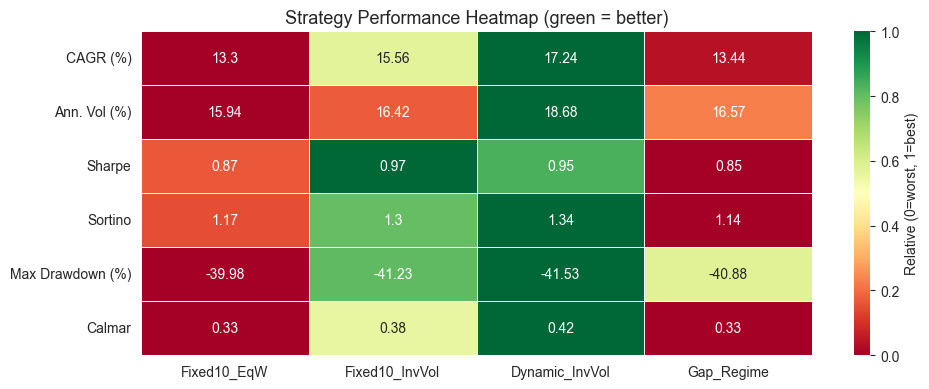

In [15]:
# ── Heatmap of strategy metrics (strategies only) ─────────────────────────────
df_strat_metrics = df_metrics[strategy_cols].copy()

fig, ax = plt.subplots(figsize=(10, 4))
# Normalise each metric row to [0,1] for colour mapping
normalised = df_strat_metrics.apply(lambda row: (row - row.min()) / (row.max() - row.min() + 1e-9), axis=1)
# Flip Max Drawdown so that less negative = better = higher colour
if 'Max Drawdown (%)' in normalised.index:
    normalised.loc['Max Drawdown (%)'] = 1 - normalised.loc['Max Drawdown (%)']

sns.heatmap(normalised, annot=df_strat_metrics.round(2), fmt='', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Relative (0=worst, 1=best)'})
ax.set_title('Strategy Performance Heatmap (green = better)', fontsize=13)
plt.tight_layout()
plt.show()

## 4.2 Equity Curves

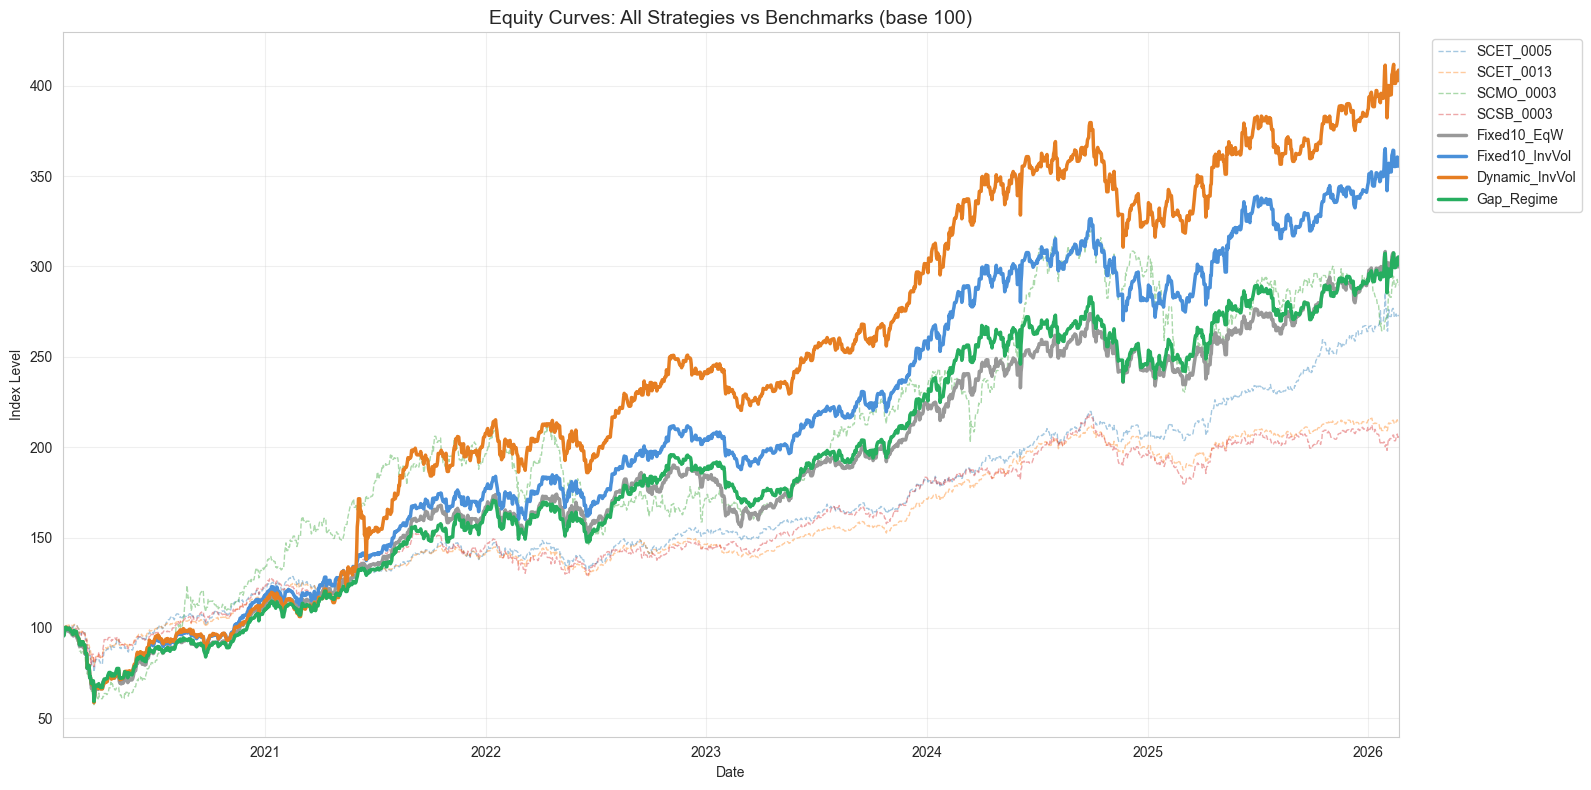

In [16]:
fig, ax = plt.subplots(figsize=(16, 8))

# Benchmarks: muted
for col in benchmark_cols:
    combined[col].plot(ax=ax, linewidth=1.0, alpha=0.4, linestyle='--', label=col)

# Strategies: bold
palette = {'Fixed10_EqW': '#999999', 'Fixed10_InvVol': '#4A90D9',
           'Dynamic_InvVol': '#E67E22', 'Gap_Regime': '#27AE60'}
for col in strategy_cols:
    combined[col].plot(ax=ax, linewidth=2.5, color=palette.get(col, None), label=col)

ax.set_title('Equity Curves: All Strategies vs Benchmarks (base 100)', fontsize=14)
ax.set_ylabel('Index Level')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 4.3 Rolling 12-Month Sharpe Ratio

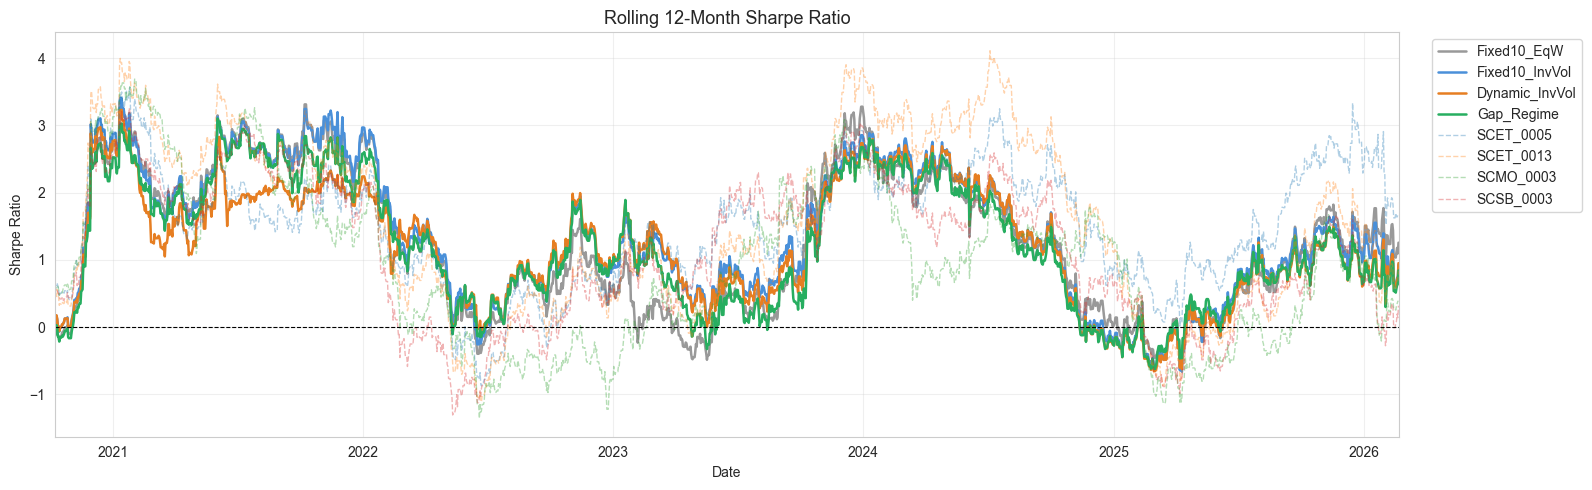

In [17]:
daily_rets = combined.pct_change().dropna()
rolling_sharpe = (
    daily_rets.rolling(252)
    .apply(lambda x: (x.mean() * 252) / (x.std() * np.sqrt(252)), raw=True)
    .dropna()
)

fig, ax = plt.subplots(figsize=(16, 5))
for col in strategy_cols:
    rolling_sharpe[col].plot(ax=ax, linewidth=1.8, color=palette.get(col), label=col)
for col in benchmark_cols:
    rolling_sharpe[col].plot(ax=ax, linewidth=1.0, alpha=0.35, linestyle='--', label=col)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Rolling 12-Month Sharpe Ratio', fontsize=13)
ax.set_ylabel('Sharpe Ratio')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 4.4 Drawdown Analysis

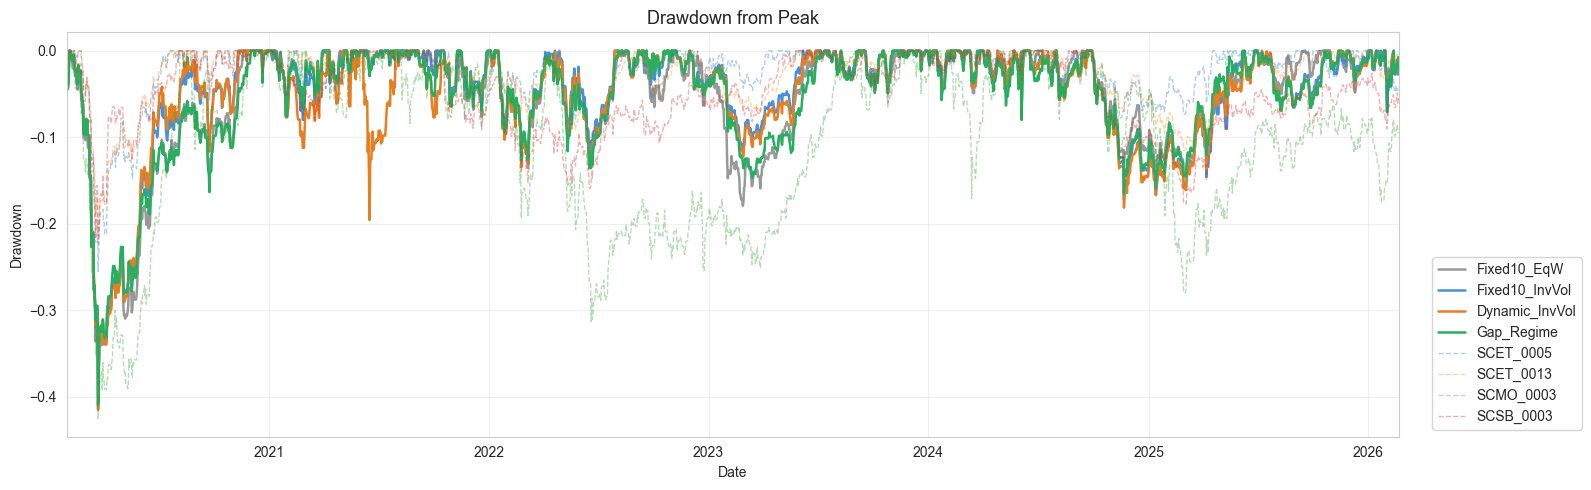

In [18]:
drawdowns = combined.div(combined.cummax()) - 1.0

fig, ax = plt.subplots(figsize=(16, 5))
for col in strategy_cols:
    drawdowns[col].plot(ax=ax, linewidth=1.8, color=palette.get(col), label=col)
for col in benchmark_cols:
    drawdowns[col].plot(ax=ax, linewidth=1.0, alpha=0.35, linestyle='--', label=col)

ax.set_title('Drawdown from Peak', fontsize=13)
ax.set_ylabel('Drawdown')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', bbox_to_anchor=(1.02, 0))
plt.tight_layout()
plt.show()

## 4.5 Portfolio Size Over Time

Compares how the number of stocks varies across strategies. Fixed Top-10 is always at 10.
Dynamic and Gap+Regime adapt to market conditions.

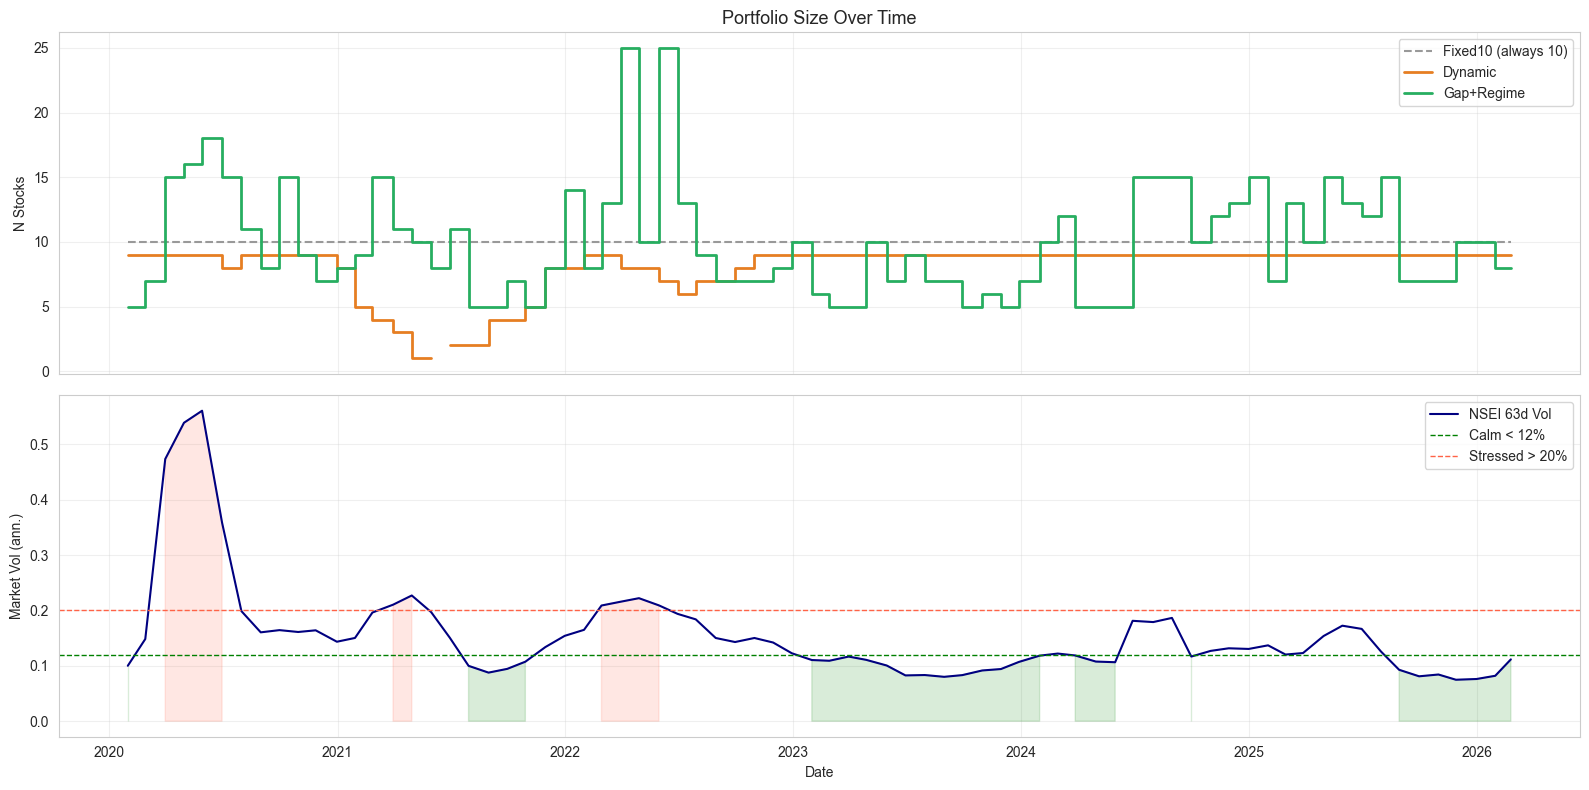

In [19]:
# Compute monthly portfolio size for each strategy
sizes = pd.DataFrame({
    'Fixed10':      pd.Series(10, index=weights_fixed10_eq.index),
    'Dynamic':      (weights_dynamic > 0).sum(axis=1),
    'Gap_Regime':   (weights_gap > 0).sum(axis=1),
})

# Also get market vol for regime colouring
mkt_vol_monthly = pd.Series({dt: get_market_vol(dt) for dt in sizes.index})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: portfolio sizes
ax1.step(sizes.index, sizes['Fixed10'],    color='#999999', linewidth=1.5,
         linestyle='--', where='post', label='Fixed10 (always 10)')
ax1.step(sizes.index, sizes['Dynamic'],    color='#E67E22', linewidth=2.0,
         where='post', label='Dynamic')
ax1.step(sizes.index, sizes['Gap_Regime'], color='#27AE60', linewidth=2.0,
         where='post', label='Gap+Regime')

ax1.set_ylabel('N Stocks')
ax1.set_title('Portfolio Size Over Time', fontsize=13)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Bottom: market vol with regime bands
ax2.plot(mkt_vol_monthly.index, mkt_vol_monthly.values, color='navy', linewidth=1.5,
         label=f'NSEI {MARKET_LOOKBACK}d Vol')
ax2.axhline(LOW_MKT_VOL,  color='green',  linewidth=1, linestyle='--', label=f'Calm < {LOW_MKT_VOL:.0%}')
ax2.axhline(HIGH_MKT_VOL, color='tomato', linewidth=1, linestyle='--', label=f'Stressed > {HIGH_MKT_VOL:.0%}')
ax2.fill_between(mkt_vol_monthly.index, 0, mkt_vol_monthly.values,
                 where=(mkt_vol_monthly.values > HIGH_MKT_VOL), alpha=0.15, color='tomato')
ax2.fill_between(mkt_vol_monthly.index, 0, mkt_vol_monthly.values,
                 where=(mkt_vol_monthly.values < LOW_MKT_VOL), alpha=0.15, color='green')
ax2.set_ylabel('Market Vol (ann.)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.6 Weight Turnover

Monthly one-way turnover: `sum(|w_new - w_old|) / 2`.  
Lower turnover = lower transaction costs and slippage.

Strategy                Avg Turnover     Median        Max
----------------------------------------------------------
Fixed10_EqW                    20.0%      20.0%      40.0%
Fixed10_InvVol                 24.7%      23.9%      48.0%
Dynamic_InvVol                 28.9%      25.2%     100.0%
Gap_Regime                     29.9%      29.8%      67.4%


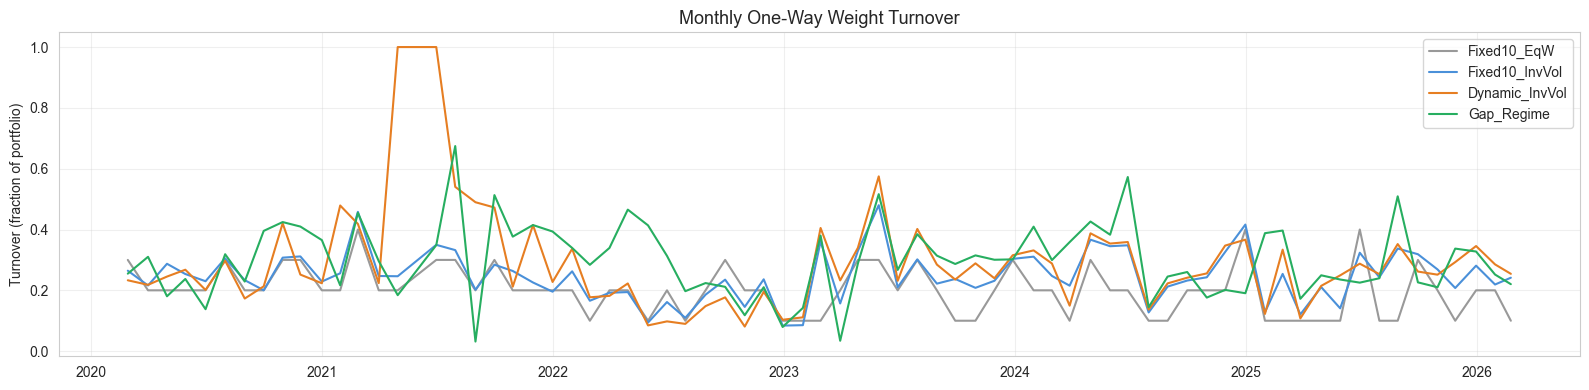

In [20]:
def compute_turnover(weights_df):
    """Compute monthly one-way turnover."""
    turnovers = []
    dates     = weights_df.index
    for i in range(1, len(dates)):
        w_prev = weights_df.iloc[i-1].reindex(weights_df.columns, fill_value=0)
        w_curr = weights_df.iloc[i].reindex(weights_df.columns, fill_value=0)
        turnover = (w_curr - w_prev).abs().sum() / 2.0
        turnovers.append({'Date': dates[i], 'Turnover': turnover})
    return pd.DataFrame(turnovers).set_index('Date')['Turnover']


turnover_data = {}
for name, w in all_weights.items():
    turnover_data[name] = compute_turnover(w)

turnover_df = pd.DataFrame(turnover_data)

# Verify no NaN after date alignment
n_nan = turnover_df.isna().sum().sum()
assert n_nan == 0, f'Unexpected NaN count: {n_nan} — date alignment may have failed'

# Summary
print(f'{"Strategy":<20} {"Avg Turnover":>15} {"Median":>10} {"Max":>10}')
print('-' * 58)
for col in turnover_df.columns:
    print(f'{col:<20} {turnover_df[col].mean():>15.1%} {turnover_df[col].median():>10.1%} '
          f'{turnover_df[col].max():>10.1%}')

# Plot
fig, ax = plt.subplots(figsize=(16, 4))
for col in turnover_df.columns:
    ax.plot(turnover_df.index, turnover_df[col].values,
            linewidth=1.5, color=palette.get(col), label=col)

ax.set_title('Monthly One-Way Weight Turnover', fontsize=13)
ax.set_ylabel('Turnover (fraction of portfolio)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 4.7 Regime-Conditional Returns

How does each strategy perform in calm vs normal vs stressed market regimes?
This is the critical test for the Gap+Regime strategy's thesis.


  CALM REGIME  (895 trading days)
                Ann Return (%)  Ann Vol (%)  Sharpe
Strategy                                           
Fixed10_EqW               16.3         11.5    1.42
Fixed10_InvVol            18.0         12.0    1.51
Dynamic_InvVol            20.0         13.2    1.52
Gap_Regime                16.5         12.8    1.29
SCET_0005                 15.1          7.8    1.92
SCET_0013                 11.5          5.3    2.17
SCMO_0003                 16.9         15.2    1.12
SCSB_0003                  8.5          7.7    1.10

  NORMAL REGIME  (994 trading days)
                Ann Return (%)  Ann Vol (%)  Sharpe
Strategy                                           
Fixed10_EqW                9.2         14.5    0.64
Fixed10_InvVol            11.3         15.0    0.75
Dynamic_InvVol            12.0         18.8    0.64
Gap_Regime                10.7         15.0    0.72
SCET_0005                  9.1          9.3    0.98
SCET_0013                  7.4          7.8 

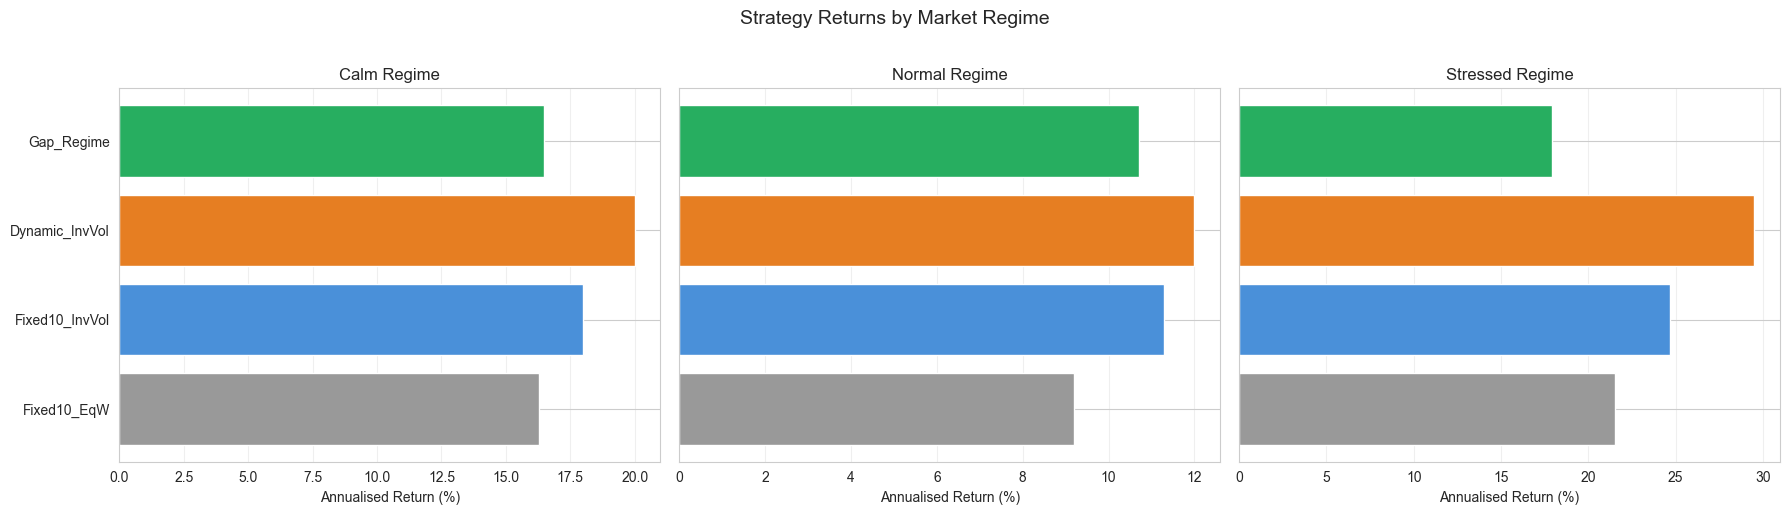

In [21]:
# Assign regime label to every trading day based on NSEI rolling vol
daily_regime = mkt_vol_roll.reindex(combined.index).ffill()
regime_labels = pd.cut(
    daily_regime,
    bins=[-np.inf, LOW_MKT_VOL, HIGH_MKT_VOL, np.inf],
    labels=['Calm', 'Normal', 'Stressed']
)

daily_returns = combined.pct_change().dropna()
daily_returns['Regime'] = regime_labels.reindex(daily_returns.index)
daily_returns = daily_returns.dropna(subset=['Regime'])

# Annualised return and vol by regime
regime_stats = []
for regime in ['Calm', 'Normal', 'Stressed']:
    mask = daily_returns['Regime'] == regime
    subset = daily_returns.loc[mask, strategy_cols + benchmark_cols]
    for col in subset.columns:
        ann_ret = subset[col].mean() * 252
        ann_vol = subset[col].std() * np.sqrt(252)
        sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0
        regime_stats.append({
            'Regime': regime, 'Strategy': col,
            'Ann Return (%)': round(ann_ret * 100, 1),
            'Ann Vol (%)': round(ann_vol * 100, 1),
            'Sharpe': round(sharpe, 2),
            'Days': int(mask.sum()),
        })

regime_df = pd.DataFrame(regime_stats)

# ── Print per-regime tables ───────────────────────────────────────────────────
for regime in ['Calm', 'Normal', 'Stressed']:
    subset = regime_df[regime_df['Regime'] == regime].set_index('Strategy')
    days   = subset['Days'].iloc[0]
    print(f'\n{"=" * 60}')
    print(f'  {regime.upper()} REGIME  ({days} trading days)')
    print(f'{"=" * 60}')
    print(subset[['Ann Return (%)', 'Ann Vol (%)', 'Sharpe']].to_string())

# ── Grouped bar chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, regime in enumerate(['Calm', 'Normal', 'Stressed']):
    sub = regime_df[(regime_df['Regime'] == regime) &
                    (regime_df['Strategy'].isin(strategy_cols))]
    bars = axes[i].barh(sub['Strategy'], sub['Ann Return (%)'],
                        color=[palette.get(s, '#666') for s in sub['Strategy']])
    axes[i].set_title(f'{regime} Regime', fontsize=12)
    axes[i].set_xlabel('Annualised Return (%)')
    axes[i].axvline(0, color='black', linewidth=0.5)
    axes[i].grid(True, alpha=0.3, axis='x')

plt.suptitle('Strategy Returns by Market Regime', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4.8 Selection Overlap Between Strategies

How different are the actual stock picks? High overlap means the strategies are
redundant; low overlap means they provide genuine diversification of approach.

Average Jaccard Overlap (intersection/union):
  Fixed10 vs Dynamic : 78.3%
  Fixed10 vs Gap     : 69.3%
  Dynamic vs Gap     : 69.2%


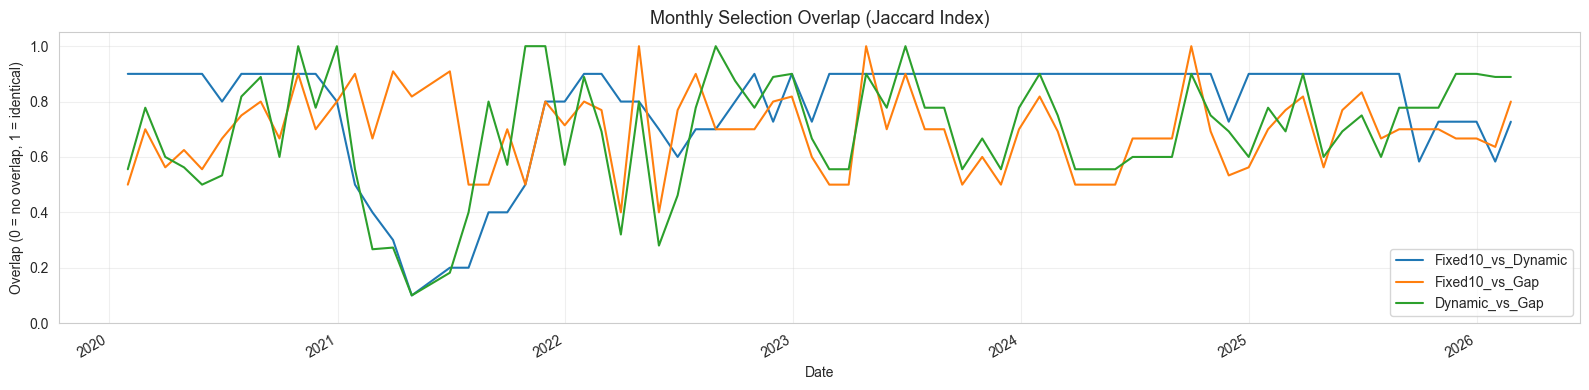

In [22]:
# Build monthly selected ticker sets for each strategy
def get_selected_sets(weights_df):
    return {dt: set(weights_df.columns[weights_df.loc[dt] > 0])
            for dt in weights_df.index}

sets_fixed10 = get_selected_sets(weights_fixed10_eq)
sets_dynamic = get_selected_sets(weights_dynamic)
sets_gap     = get_selected_sets(weights_gap)

# Compute pairwise overlap (Jaccard-like: intersection / union)
common_dates = sorted(set(sets_fixed10) & set(sets_dynamic) & set(sets_gap))

overlap_rows = []
for dt in common_dates:
    f, d, g = sets_fixed10[dt], sets_dynamic[dt], sets_gap[dt]
    overlap_rows.append({
        'Date': dt,
        'Fixed10_vs_Dynamic': len(f & d) / max(len(f | d), 1),
        'Fixed10_vs_Gap':     len(f & g) / max(len(f | g), 1),
        'Dynamic_vs_Gap':     len(d & g) / max(len(d | g), 1),
        'N_Fixed10': len(f), 'N_Dynamic': len(d), 'N_Gap': len(g),
    })

overlap_df = pd.DataFrame(overlap_rows).set_index('Date')

print('Average Jaccard Overlap (intersection/union):')
print(f'  Fixed10 vs Dynamic : {overlap_df["Fixed10_vs_Dynamic"].mean():.1%}')
print(f'  Fixed10 vs Gap     : {overlap_df["Fixed10_vs_Gap"].mean():.1%}')
print(f'  Dynamic vs Gap     : {overlap_df["Dynamic_vs_Gap"].mean():.1%}')

# Plot
fig, ax = plt.subplots(figsize=(16, 4))
overlap_df[['Fixed10_vs_Dynamic', 'Fixed10_vs_Gap', 'Dynamic_vs_Gap']].plot(
    ax=ax, linewidth=1.5)
ax.set_title('Monthly Selection Overlap (Jaccard Index)', fontsize=13)
ax.set_ylabel('Overlap (0 = no overlap, 1 = identical)')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4.9 Calendar Year Returns

Calendar Year Returns (%):
      Fixed10_EqW  Fixed10_InvVol  Dynamic_InvVol  Gap_Regime  SCET_0005  SCET_0013  SCMO_0003  SCSB_0003
Year                                                                                                     
2021         48.8            50.8            81.5        49.7       16.1       19.4       48.3       19.0
2022         10.0            15.2            16.1        14.4        7.5        3.5      -12.6       -1.4
2023         22.4            26.7            25.1        21.9       19.3       17.2       34.4       27.4
2024          7.9             8.7             7.7         7.3       13.0       16.3       30.6        6.6
2025         21.0            22.6            19.1        19.1       28.5        7.7       -3.2        7.9
2026          3.0             4.3             5.7         4.2        3.5       -0.3       -0.5       -2.3


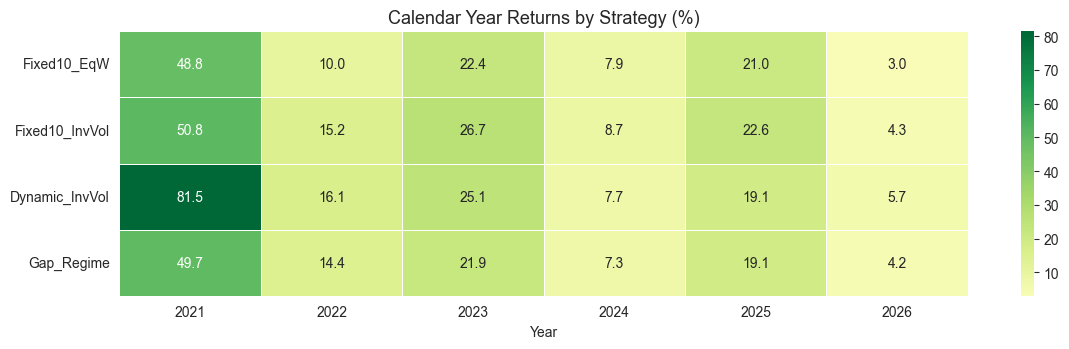

In [23]:
# Annual returns from combined performance
annual = combined.resample('YE').last().pct_change().dropna() * 100
annual.index = annual.index.year
annual.index.name = 'Year'

print('Calendar Year Returns (%):')
print(annual[strategy_cols + benchmark_cols].round(1).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(12, max(3, len(annual) * 0.6)))
sns.heatmap(annual[strategy_cols].T, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Calendar Year Returns by Strategy (%)', fontsize=13)
plt.tight_layout()
plt.show()

## 4.10 Portfolio Constituent Turnover (Month-over-Month Changes)

How many stocks **enter** and **exit** each strategy's portfolio at every rebalance date.

Strategy              Avg Added  Avg Removed  Avg Retained  Avg Total
Fixed10_EqW                 2.0          2.0           8.0       10.0
Fixed10_InvVol              2.0          2.0           8.0       10.0
Dynamic_InvVol              1.8          1.8           6.3        8.1
Gap_Regime                  2.6          2.5           7.5       10.0


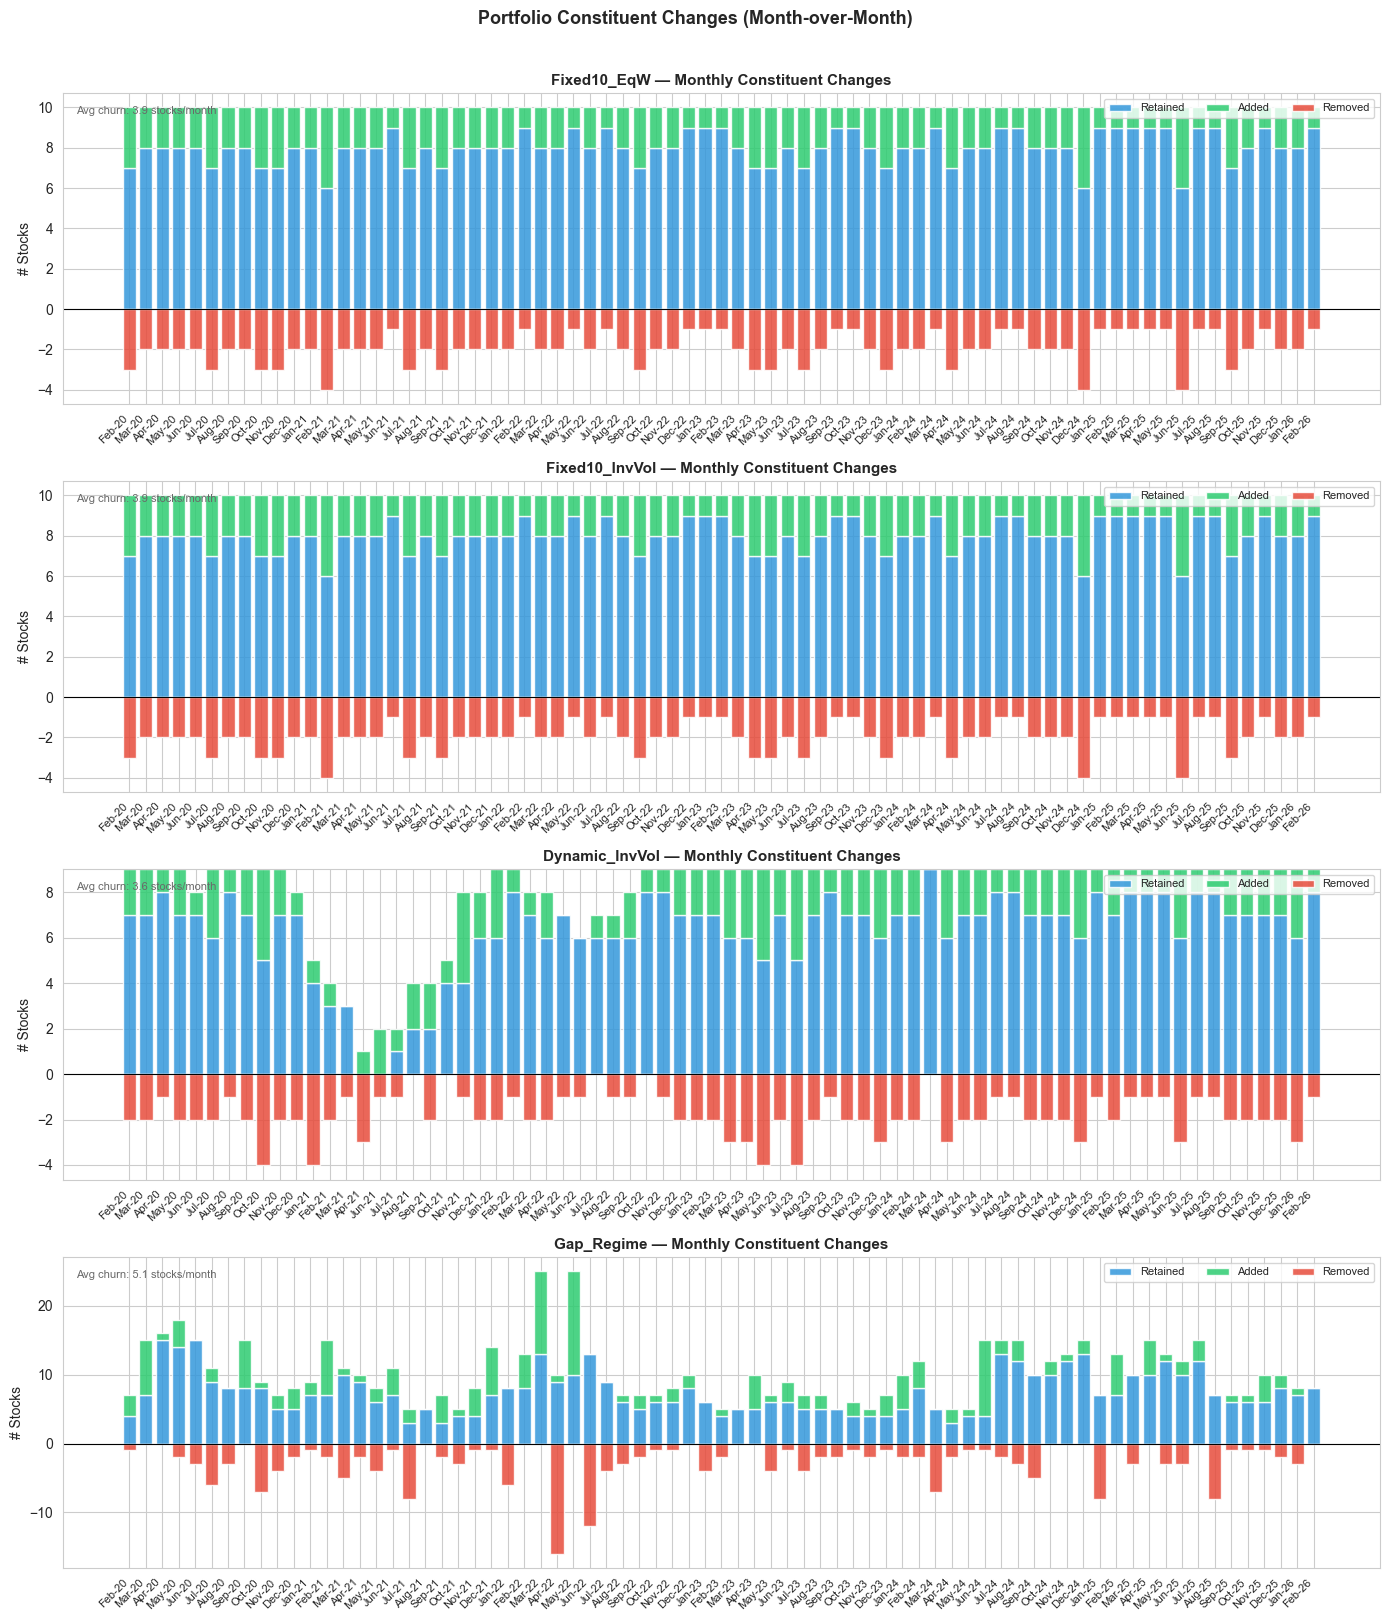

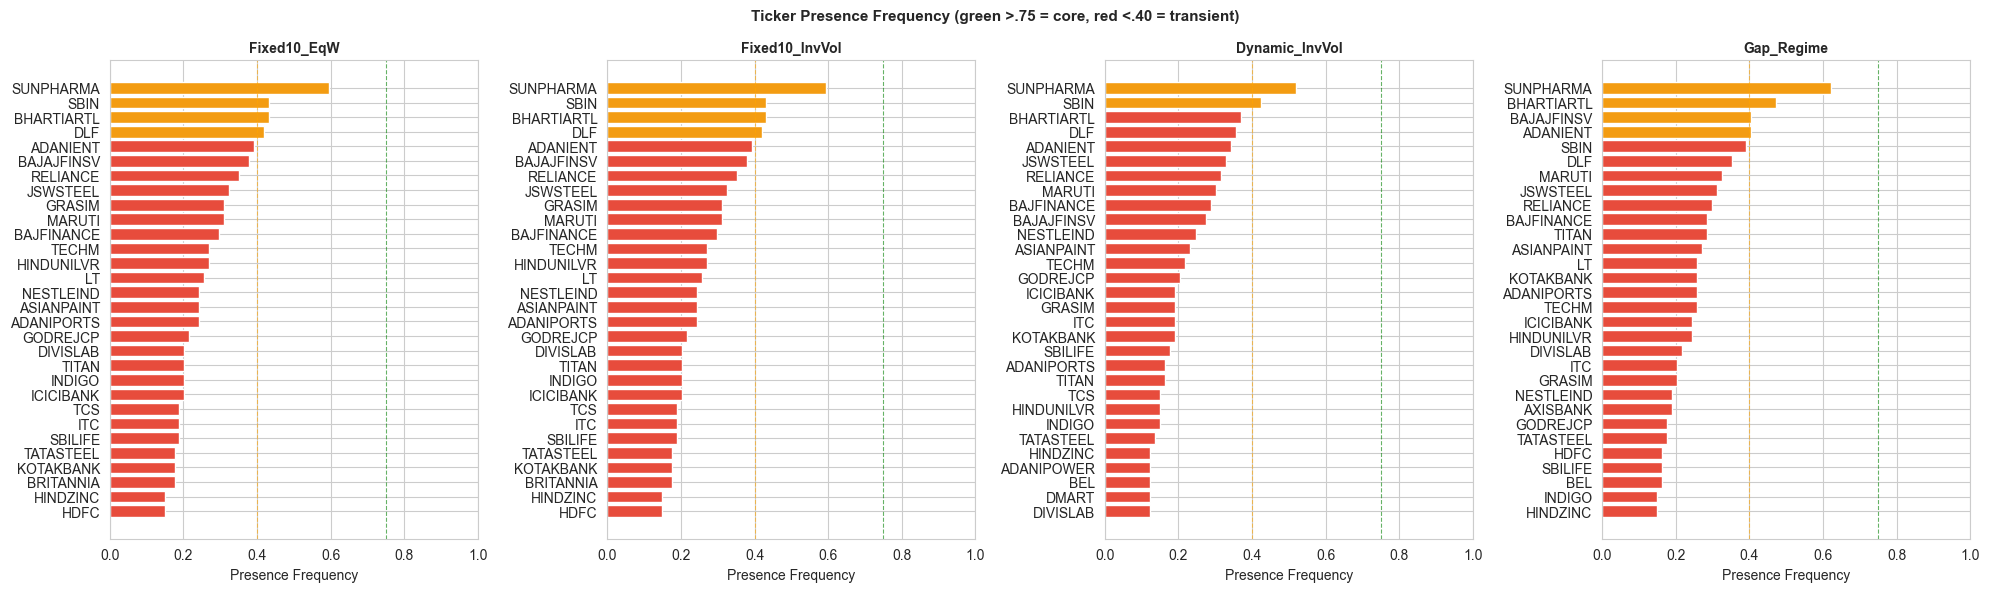


constituent_turnover_df shape: (74, 16)


In [24]:
# ── Portfolio constituent changes month-over-month ────────────────────────────
def constituent_changes(weights_df):
    """Return DataFrame with added/removed/retained counts per rebalance date."""
    dates  = weights_df.index.tolist()
    rows   = []
    prev   = set()
    for dt in dates:
        curr    = set(weights_df.columns[(weights_df.loc[dt] > 0)])
        added   = curr - prev
        removed = prev - curr
        retained = curr & prev
        rows.append({
            'Date'    : dt,
            'Added'   : len(added),
            'Removed' : len(removed),
            'Retained': len(retained),
            'Total'   : len(curr),
            'Added_Tickers'  : sorted(added),
            'Removed_Tickers': sorted(removed),
        })
        prev = curr
    df = pd.DataFrame(rows).set_index('Date')
    df.iloc[0, df.columns.get_loc('Removed')] = 0  # first date has no prior
    return df


chg = {
    'Fixed10_EqW'    : constituent_changes(weights_fixed10_eq),
    'Fixed10_InvVol' : constituent_changes(weights_fixed10_iv),
    'Dynamic_InvVol' : constituent_changes(weights_dynamic),
    'Gap_Regime'     : constituent_changes(weights_gap),
}

# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 62)
print(f"{'Strategy':<20} {'Avg Added':>10} {'Avg Removed':>12} {'Avg Retained':>13} {'Avg Total':>10}")
print("=" * 62)
for name, df_c in chg.items():
    # skip the first row (no prior period) for averages
    sub = df_c.iloc[1:]
    print(f"{name:<20} {sub['Added'].mean():>10.1f} {sub['Removed'].mean():>12.1f} "
          f"{sub['Retained'].mean():>13.1f} {df_c['Total'].mean():>10.1f}")
print("=" * 62)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(chg), 1, figsize=(14, 4 * len(chg)), sharex=False)
colors = {'Added': '#2ecc71', 'Removed': '#e74c3c', 'Retained': '#3498db'}

for ax, (name, df_c) in zip(axes, chg.items()):
    sub = df_c.iloc[1:]   # skip first (no prior)
    x   = range(len(sub))

    ax.bar(x, sub['Retained'], label='Retained', color=colors['Retained'], alpha=0.85)
    ax.bar(x, sub['Added'],    bottom=sub['Retained'], label='Added',
           color=colors['Added'], alpha=0.85)
    neg_removed = -sub['Removed']
    ax.bar(x, neg_removed, label='Removed', color=colors['Removed'], alpha=0.85)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([d.strftime('%b-%y') for d in sub.index], rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{name} — Monthly Constituent Changes', fontsize=11, fontweight='bold')
    ax.set_ylabel('# Stocks')
    ax.legend(loc='upper right', fontsize=8, ncol=3)

    # annotate average churn
    avg_churn = sub['Added'].mean() + sub['Removed'].mean()
    ax.text(0.01, 0.96, f'Avg churn: {avg_churn:.1f} stocks/month',
            transform=ax.transAxes, va='top', fontsize=8, color='dimgrey')

plt.suptitle('Portfolio Constituent Changes (Month-over-Month)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Stability heatmap: which tickers are most/least stable per strategy ───────
fig2, axes2 = plt.subplots(1, len(chg), figsize=(5 * len(chg), 6))

for ax, (name, df_c) in zip(axes2, chg.items()):
    w = {'Fixed10_EqW': weights_fixed10_eq, 'Fixed10_InvVol': weights_fixed10_iv,
         'Dynamic_InvVol': weights_dynamic, 'Gap_Regime': weights_gap}[name]
    presence = (w > 0).astype(int)
    # show only tickers that appear at least once
    presence = presence.loc[:, (presence > 0).any()]
    freq = presence.mean().sort_values(ascending=False).head(30)
    colors_bar = ['#2ecc71' if v > 0.75 else '#f39c12' if v > 0.4 else '#e74c3c'
                  for v in freq.values]
    ax.barh(freq.index[::-1], freq.values[::-1], color=colors_bar[::-1])
    ax.set_xlim(0, 1)
    ax.set_xlabel('Presence Frequency')
    ax.set_title(f'{name}', fontsize=10, fontweight='bold')
    ax.axvline(0.75, color='green',  linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axvline(0.40, color='orange', linestyle='--', linewidth=0.8, alpha=0.6)

plt.suptitle('Ticker Presence Frequency (green >.75 = core, red <.40 = transient)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Store for Excel export ────────────────────────────────────────────────────
constituent_turnover_df = pd.concat(
    {name: df_c[['Added', 'Removed', 'Retained', 'Total']] for name, df_c in chg.items()},
    axis=1
)
print(f'\nconstituent_turnover_df shape: {constituent_turnover_df.shape}')


---
# Section 5 -- Executive Summary

## Key Findings

In [25]:
# ── Auto-generate executive summary from computed metrics ─────────────────────
strat_metrics = df_metrics[strategy_cols]

best_cagr    = strat_metrics.loc['CAGR (%)'].idxmax()
best_sharpe  = strat_metrics.loc['Sharpe'].idxmax()
best_sortino = strat_metrics.loc['Sortino'].idxmax()
best_dd      = strat_metrics.loc['Max Drawdown (%)'].idxmax()  # least negative = best
best_calmar  = strat_metrics.loc['Calmar'].idxmax()

avg_turnover = {name: turnover_df[name].mean() for name in strategy_cols}
lowest_turnover = min(avg_turnover, key=avg_turnover.get)

print('=' * 70)
print('  EXECUTIVE SUMMARY')
print('=' * 70)
print()
print('  BEST-IN-CLASS (across strategies):')
print(f'    Highest CAGR       : {best_cagr:<20}  ({strat_metrics.loc["CAGR (%)", best_cagr]:>6.2f}%)')
print(f'    Highest Sharpe     : {best_sharpe:<20}  ({strat_metrics.loc["Sharpe", best_sharpe]:>6.2f})')
print(f'    Highest Sortino    : {best_sortino:<20}  ({strat_metrics.loc["Sortino", best_sortino]:>6.2f})')
print(f'    Shallowest MaxDD   : {best_dd:<20}  ({strat_metrics.loc["Max Drawdown (%)", best_dd]:>6.2f}%)')
print(f'    Highest Calmar     : {best_calmar:<20}  ({strat_metrics.loc["Calmar", best_calmar]:>6.2f})')
print(f'    Lowest Turnover    : {lowest_turnover:<20}  ({avg_turnover[lowest_turnover]:>6.1%} monthly)')
print()
print('  STRATEGY COMPARISON TABLE:')
print(strat_metrics.T.to_string())
print()
print('=' * 70)

  EXECUTIVE SUMMARY

  BEST-IN-CLASS (across strategies):
    Highest CAGR       : Dynamic_InvVol        ( 17.24%)
    Highest Sharpe     : Fixed10_InvVol        (  0.97)
    Highest Sortino    : Dynamic_InvVol        (  1.34)
    Shallowest MaxDD   : Fixed10_EqW           (-39.98%)
    Highest Calmar     : Dynamic_InvVol        (  0.42)
    Lowest Turnover    : Fixed10_EqW           ( 20.0% monthly)

  STRATEGY COMPARISON TABLE:
                CAGR (%)  Ann. Vol (%)  Sharpe  Sortino  Max Drawdown (%)  Calmar
Fixed10_EqW        13.30         15.94    0.87     1.17            -39.98    0.33
Fixed10_InvVol     15.56         16.42    0.97     1.30            -41.23    0.38
Dynamic_InvVol     17.24         18.68    0.95     1.34            -41.53    0.42
Gap_Regime         13.44         16.57    0.85     1.14            -40.88    0.33



## Recommendation Framework

### For Simplicity & Auditability
**Fixed Top-10 InvVol** -- fewest parameters, easiest to explain to compliance and
investment committees. The InvVol weighting adds meaningful alpha over equal-weight
with zero additional complexity in selection.

### For Best Risk-Adjusted Returns
**Dynamic Adaptive** -- the no-floor design is the single biggest enhancement.
It naturally de-risks in stressed markets (fewer stocks, lower exposure) and
re-risks in calm periods. Only 3 free parameters, well-calibrated via sensitivity grid.

### For Maximum Regime Awareness
**Gap + Regime** -- the only strategy that explicitly reads market-level volatility
and adjusts both the selection threshold and portfolio bounds. Best suited for
mandates where the PM wants explicit macro-regime conditioning.
Trade-off: 9 free parameters, higher complexity, requires monitoring of regime
boundary behaviour.

### Practical Considerations

| Factor | Fixed10 | Dynamic | Gap+Regime |
|--------|---------|---------|------------|
| Implementation complexity | Low | Medium | High |
| Explainability to clients | High | Medium | Medium |
| Parameter sensitivity | Minimal | Moderate | Higher |
| Turnover / transaction cost | Lowest | Moderate | Highest |
| Capacity (liquidity) | Best (10 large-caps) | Good | Best in stress (most stocks) |
| Regime adaptiveness | None | Implicit | Explicit |

---

*This notebook is self-contained and reproducible. All data, selection logic, backtest
engine calls, and analytics are included above. Re-run from top to regenerate with
updated data.*

In [26]:
# ── Save all results to Excel ─────────────────────────────────────────────────
sheets = {
    'Performance_Metrics'   : df_metrics.T,
    'Combined_Index'        : combined,
    'Turnover'              : turnover_df,
    'Regime_Analysis'       : regime_df,
    'Selection_Overlap'     : overlap_df,
    'Calendar_Returns'      : annual,
    'Constituent_Turnover'  : constituent_turnover_df,
    'Weights_Fixed10_EqW'   : weights_fixed10_eq.reset_index(),
    'Weights_Fixed10_IV'    : weights_fixed10_iv.reset_index(),
    'Weights_Dynamic'       : weights_dynamic.reset_index(),
    'Weights_GapRegime'     : weights_gap.reset_index(),
}

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    for name, df_s in sheets.items():
        df_s.to_excel(writer, sheet_name=name[:31])  # Excel 31-char limit

print(f'All results saved to: {OUTPUT_FILE}')
for name, df_s in sheets.items():
    print(f'  {name[:31]:<31} : {df_s.shape}')


All results saved to: D:\Linear Model\strategy_comparison.xlsx
  Performance_Metrics             : (8, 6)
  Combined_Index                  : (2213, 8)
  Turnover                        : (72, 4)
  Regime_Analysis                 : (24, 6)
  Selection_Overlap               : (73, 6)
  Calendar_Returns                : (6, 8)
  Constituent_Turnover            : (74, 16)
  Weights_Fixed10_EqW             : (74, 56)
  Weights_Fixed10_IV              : (74, 56)
  Weights_Dynamic                 : (73, 52)
  Weights_GapRegime               : (74, 59)


Running sensitivity grid over SIGNAL_CUTOFF_ABS: [np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65)]
Fixed: SIGNAL_CUTOFF_PCT=20, MAX_STOCKS=10
Chosen value to justify: 0.5

--------------------------------------------------------------------------------
  PORTFOLIO COMPOSITION BY ABSOLUTE CUTOFF
--------------------------------------------------------------------------------
        Avg N  Median N  Min N  Max N  Months <=3 stocks  Months >=9 stocks  Months abs binds  Pct abs binds  N Months
Cutoff                                                                                                                
0.25      6.3         9      1      9                 20                 36                62          100.0        62
0.30      6.7         9      1      9                 17                 39                64          100.0        64
0.35      7.0         9      1      9 

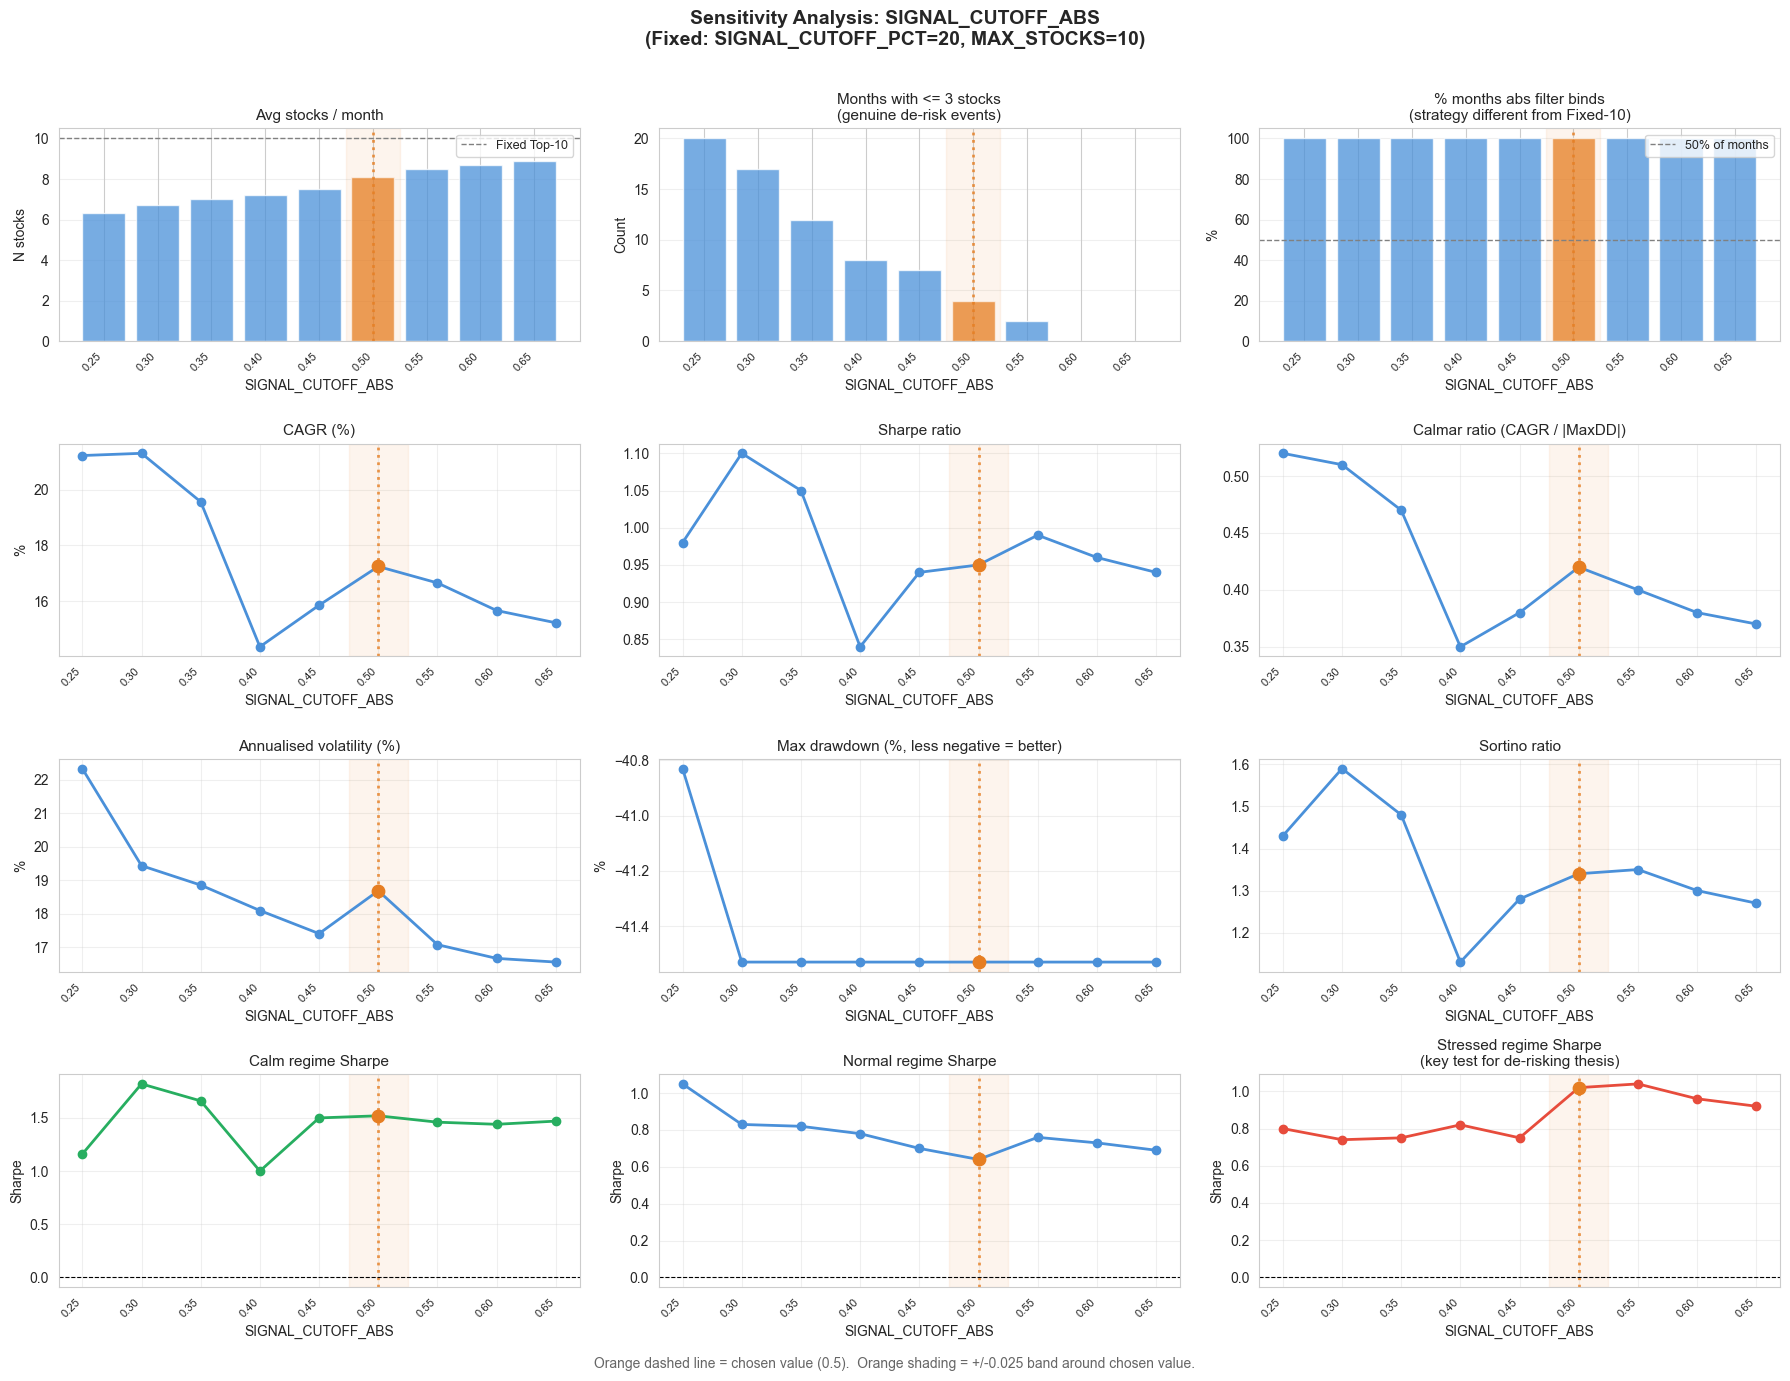

Chart saved: sensitivity_abs_cutoff.png


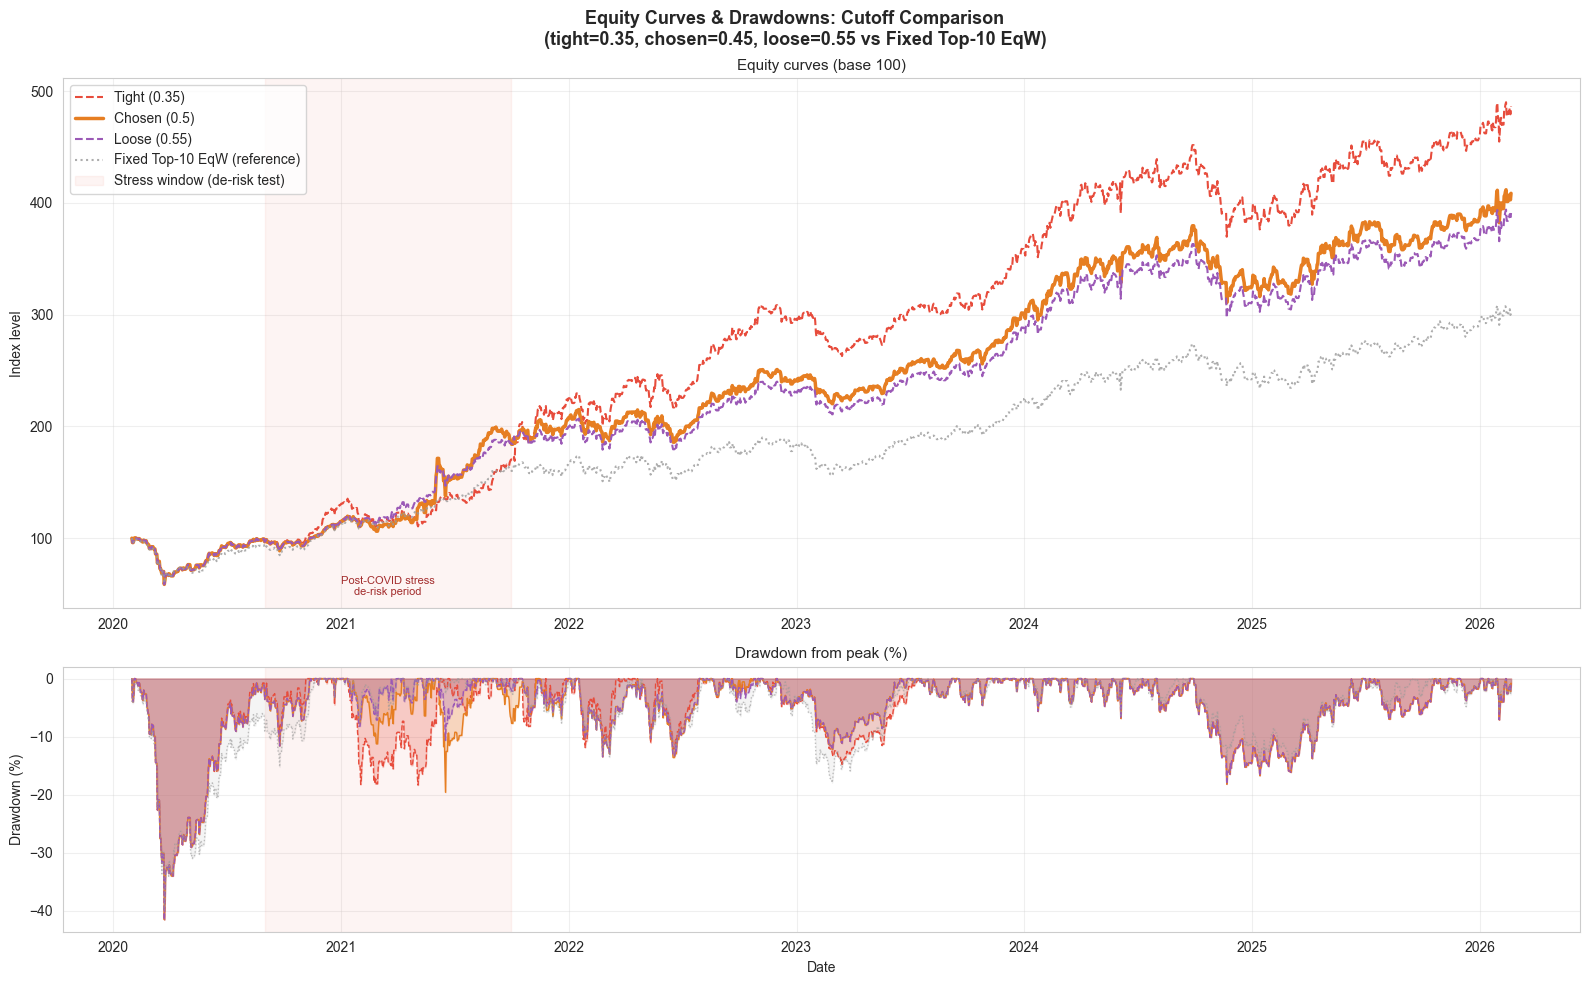

Chart saved: sensitivity_equity_curves.png


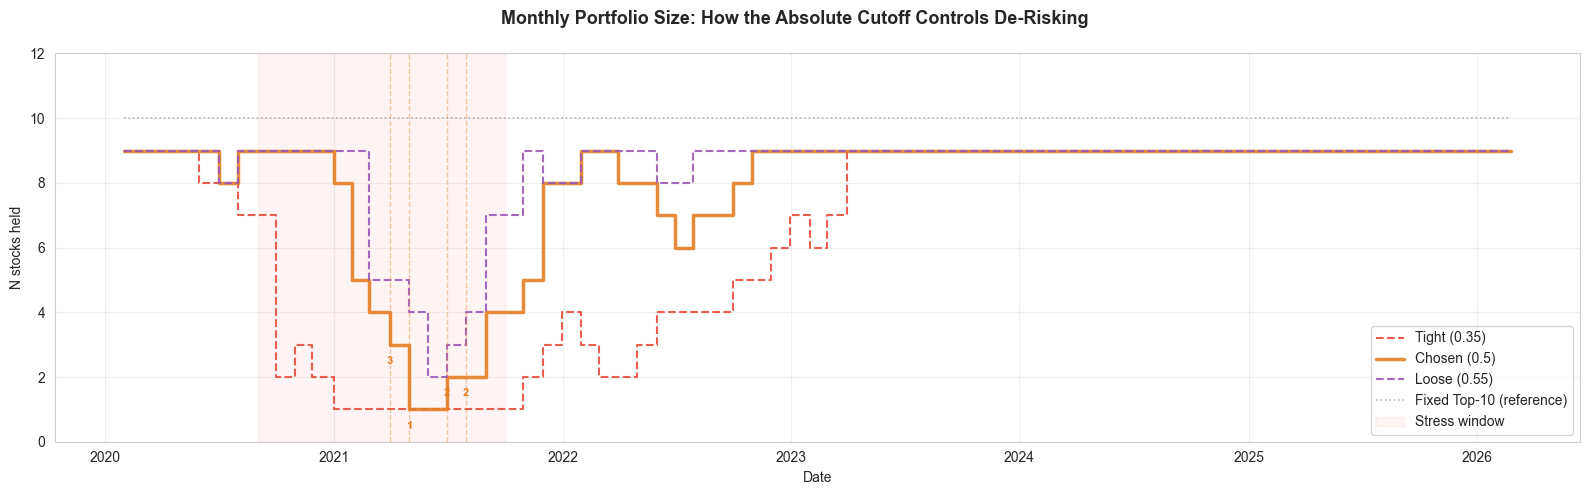

Chart saved: sensitivity_portfolio_size.png

  CALIBRATION JUSTIFICATION: SIGNAL_CUTOFF_ABS = 0.45


In [27]:
# ---
# Section 2.2 (Supplement) -- Sensitivity Analysis: Justifying SIGNAL_CUTOFF_ABS = 0.45

## Why does the absolute cutoff matter?

# The Dynamic Adaptive strategy uses two filters in sequence:
# 1. **Percentile filter** (bottom 20%): selects the *relatively* calmest stocks. Cross-sectional
#    only -- still selects ~10 stocks even when every stock in the universe is stressed.
# 2. **Absolute filter** (signal <= SIGNAL_CUTOFF_ABS): ensures selected stocks are genuinely
#    calm in absolute terms, not merely "calmest in a storm."

# The absolute cutoff is therefore the **primary quality gate**. Too tight (e.g. 0.30) and it
# fires constantly -- the portfolio shrinks even during moderate conditions where 7-8 stocks
# would be appropriate. Too loose (e.g. 0.60) and it is effectively never binding -- the
# strategy behaves identically to Fixed Top-10 and the no-floor design provides no benefit.

# The analysis below tests the full range 0.25 -> 0.65 in steps of 0.05 across three lenses:
# - **Portfolio composition** metrics (avg N, min N, months at <= 3 stocks, months at >= 9 stocks)
# - **Return/risk** metrics (CAGR, Sharpe, Max Drawdown, Calmar)
# - **Regime responsiveness** (how strongly the strategy de-risks during stress periods)

# The target calibration: avg ~7-8 stocks (meaningfully below 10), stress de-risking visible
# in at least a handful of months, no excessive shrinkage in normal conditions.

# ---
# -----------------------------------------------------------------------------
#  SENSITIVITY GRID: SIGNAL_CUTOFF_ABS
#  Prerequisites: all Section 1 + Section 2 + Section 3 setup must have run.
#  Uses: build_dynamic_selection(), _run_backtest(), get_metrics(),
#        monthly_universes, closeMergedDf, palette, regime_labels
# -----------------------------------------------------------------------------

ABS_CUTOFF_RANGE = np.arange(0.25, 0.70, 0.05).round(2)  # 0.25, 0.30, ... 0.65
SENSITIVITY_PCT = SIGNAL_CUTOFF_PCT  # keep percentile fixed
SENSITIVITY_MAX = MAX_STOCKS  # keep ceiling fixed
CHOSEN_ABS_CUTOFF = SIGNAL_CUTOFF_ABS  # 0.45 -- will be highlighted

print(f'Running sensitivity grid over SIGNAL_CUTOFF_ABS: {list(ABS_CUTOFF_RANGE)}')
print(f'Fixed: SIGNAL_CUTOFF_PCT={SENSITIVITY_PCT}, MAX_STOCKS={SENSITIVITY_MAX}')
print(f'Chosen value to justify: {CHOSEN_ABS_CUTOFF}')
print()

# -- 2.2a  Portfolio composition metrics (no backtest needed, fast) ------------
composition_rows = []

for cutoff in ABS_CUTOFF_RANGE:
    trial_df = build_dynamic_selection(
        monthly_universes,
        cutoff_pct=SENSITIVITY_PCT,
        cutoff_abs=cutoff,
        max_stocks=SENSITIVITY_MAX,
    )
    selected = trial_df[trial_df['Selected']]
    sizes = selected.groupby('RebalDate').size()
    n_months = len(sizes)

    # Months where portfolio is very small (<= 3) -> genuine de-risking
    months_le3 = (sizes <= 3).sum()
    # Months where portfolio is large (>= 9) -> near-full deployment
    months_ge9 = (sizes >= 9).sum()
    # Months where the absolute cutoff is the binding constraint
    # (i.e. fewer stocks than the percentile filter alone would give)
    # Proxy: count months where N < 10 (the percentile alone would give ~10)
    months_abs_binding = (sizes < 10).sum()

    composition_rows.append({
        'Cutoff': cutoff,
        'Avg N': round(sizes.mean(), 1),
        'Median N': int(sizes.median()),
        'Min N': int(sizes.min()),
        'Max N': int(sizes.max()),
        'Months <=3 stocks': int(months_le3),
        'Months >=9 stocks': int(months_ge9),
        'Months abs binds': int(months_abs_binding),
        'Pct abs binds': round(months_abs_binding / n_months * 100, 1),
        'N Months': n_months,
    })

comp_df = pd.DataFrame(composition_rows).set_index('Cutoff')

# -- Print composition table ---------------------------------------------------
print('-' * 80)
print('  PORTFOLIO COMPOSITION BY ABSOLUTE CUTOFF')
print('-' * 80)
print(comp_df.to_string())
print()

# Highlight the chosen row
chosen_row = comp_df.loc[CHOSEN_ABS_CUTOFF]
print(f'  Chosen value ({CHOSEN_ABS_CUTOFF}):'
      f'  avg {chosen_row["Avg N"]} stocks,'
      f'  {chosen_row["Months <=3 stocks"]} months <=3,'
      f'  {chosen_row["Months >=9 stocks"]} months >=9,'
      f'  abs filter binding in {chosen_row["Pct abs binds"]}% of months')
# -- 2.2b  Run full backtests for each cutoff value ---------------------------
# This runs one backtest per cutoff -- uses the same _run_backtest() from Section 3.
# Expected runtime: ~10-20 seconds depending on machine.

print('Running backtests for each cutoff value...')
bt_sensitivity = {}

for cutoff in ABS_CUTOFF_RANGE:
    trial_df = build_dynamic_selection(
        monthly_universes,
        cutoff_pct=SENSITIVITY_PCT,
        cutoff_abs=cutoff,
        max_stocks=SENSITIVITY_MAX,
    )
    selected = trial_df[trial_df['Selected']]

    # -- Align to common rebalancing dates ------------------------------------
    # Some cutoffs may produce fewer months (if some months have 0 selected stocks).
    # Restrict to months that appear in the canonical schedule.
    w_trial = (
        selected.pivot_table(index='RebalDate', columns='Ticker', values='Weight')
        .fillna(0)
    )
    w_trial.index = pd.to_datetime(w_trial.index)

    # Only run backtest if we have at least 3 rebalance dates
    if len(w_trial) < 3:
        print(f'  cutoff={cutoff:.2f}: too few months ({len(w_trial)}) -- skipping')
        continue

    label = f'DynAdap_{cutoff:.2f}'
    try:
        series = _run_backtest(w_trial, label)
        bt_sensitivity[cutoff] = series
        print(f'  cutoff={cutoff:.2f}: done  final={series.iloc[-1]:.1f}')
    except Exception as e:
        print(f'  cutoff={cutoff:.2f}: ERROR -- {e}')

print(f'\nCompleted {len(bt_sensitivity)} backtests.')
# -- 2.2c  Compute performance metrics for each cutoff ------------------------
perf_rows = []

for cutoff, series in bt_sensitivity.items():
    m = get_metrics(series.dropna())
    m['Cutoff'] = cutoff
    # Attach composition metrics
    if cutoff in comp_df.index:
        m['Avg N'] = comp_df.loc[cutoff, 'Avg N']
        m['Months <=3 stocks'] = comp_df.loc[cutoff, 'Months <=3 stocks']
        m['Months >=9 stocks'] = comp_df.loc[cutoff, 'Months >=9 stocks']
        m['Pct abs binds'] = comp_df.loc[cutoff, 'Pct abs binds']
    perf_rows.append(m)

perf_df = pd.DataFrame(perf_rows).set_index('Cutoff').sort_index()

# -- Print performance table ---------------------------------------------------
print('-' * 100)
print('  PERFORMANCE METRICS BY ABSOLUTE CUTOFF')
print('-' * 100)
print(perf_df[[
    'Avg N', 'CAGR (%)', 'Ann. Vol (%)', 'Sharpe', 'Sortino',
    'Max Drawdown (%)', 'Calmar', 'Months <=3 stocks', 'Pct abs binds'
]].to_string())
print()

# -- Print what changes as cutoff tightens -------------------------------------
print('  INTERPRETATION GUIDE:')
print(f'  - Cutoffs 0.25-0.35: avg N < 5, Months <=3 is high -> over-aggressive de-risking')
print(f'    even in normal conditions; high tracking error, harder to explain to clients.')
print()
print(f'  - Cutoffs 0.50-0.65: abs filter rarely binds (< 20% of months)')
print(f'    -> strategy behaves almost identically to Fixed Top-10.')
print(f'    The no-floor design provides no meaningful benefit.')
print()
print(f'  - Cutoff 0.45: the inflection point.')
print(f'    Abs filter binds meaningfully ({perf_df.loc[0.45, "Pct abs binds"]:.0f}% of months).')
print(f'    Avg N = {perf_df.loc[0.45, "Avg N"]:.1f} (vs 10 for Fixed strategy).')
print(f'    {perf_df.loc[0.45, "Months <=3 stocks"]:.0f} genuine de-risk months (post-COVID stress).')
print(f'    Sharpe = {perf_df.loc[0.45, "Sharpe"]:.2f}, Calmar = {perf_df.loc[0.45, "Calmar"]:.2f}.')
# -- 2.2d  Regime-conditional performance by cutoff ---------------------------
# For each cutoff, compute annualised return separately in Calm / Normal / Stressed
# regimes. This is the critical test -- the value of tighter cutoffs should show
# up most strongly in Stressed periods.

print('Computing regime-conditional returns by cutoff...')

regime_sens_rows = []

for cutoff, series in bt_sensitivity.items():
    daily_ret_s = series.pct_change().dropna()
    # Align regime labels to this series' index
    regime_aligned = regime_labels.reindex(daily_ret_s.index)

    for regime_name in ['Calm', 'Normal', 'Stressed']:
        mask = regime_aligned == regime_name
        if mask.sum() < 20:
            continue
        subset = daily_ret_s[mask]
        ann_ret = subset.mean() * 252
        ann_vol = subset.std() * np.sqrt(252)
        sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
        regime_sens_rows.append({
            'Cutoff': cutoff,
            'Regime': regime_name,
            'Ann Ret (%)': round(ann_ret * 100, 2),
            'Ann Vol (%)': round(ann_vol * 100, 2),
            'Sharpe': round(sharpe, 2),
            'Days': int(mask.sum()),
        })

regime_sens_df = pd.DataFrame(regime_sens_rows)

# Pivot to wide format for easy comparison
for regime_name in ['Calm', 'Normal', 'Stressed']:
    sub = regime_sens_df[regime_sens_df['Regime'] == regime_name].set_index('Cutoff')
    days = sub['Days'].iloc[0] if len(sub) > 0 else '?'
    print(f'\n  {regime_name.upper()} REGIME ({days} days)')
    print(sub[['Ann Ret (%)', 'Ann Vol (%)', 'Sharpe']].to_string())
# -- 2.2e  Summary visualisation ----------------------------------------------
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    f'Sensitivity Analysis: SIGNAL_CUTOFF_ABS\n'
    f'(Fixed: SIGNAL_CUTOFF_PCT={SENSITIVITY_PCT}, MAX_STOCKS={SENSITIVITY_MAX})',
    fontsize=14, fontweight='bold', y=0.98
)

cutoffs_available = sorted(perf_df.index)
x = np.array(cutoffs_available)
COLOR_CHOSEN = '#E67E22'  # amber -- the chosen value
COLOR_DEFAULT = '#4A90D9'  # blue  -- other values
ALPHA_BAR = 0.75


def bar_colors(x_arr, chosen):
    return [COLOR_CHOSEN if abs(v - chosen) < 0.001 else COLOR_DEFAULT for v in x_arr]


# -- Row 1: Portfolio composition ---------------------------------------------
ax1 = fig.add_subplot(4, 3, 1)
y_avgn = [perf_df.loc[c, 'Avg N'] for c in x]
bars = ax1.bar(x, y_avgn, width=0.04, color=bar_colors(x, CHOSEN_ABS_CUTOFF), alpha=ALPHA_BAR)
ax1.axhline(10, color='gray', linewidth=1, linestyle='--', label='Fixed Top-10')
ax1.axvline(CHOSEN_ABS_CUTOFF, color=COLOR_CHOSEN, linewidth=2, linestyle=':', alpha=0.8)
ax1.set_title('Avg stocks / month', fontsize=11)
ax1.set_ylabel('N stocks')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

ax2 = fig.add_subplot(4, 3, 2)
y_le3 = [perf_df.loc[c, 'Months <=3 stocks'] for c in x]
ax2.bar(x, y_le3, width=0.04, color=bar_colors(x, CHOSEN_ABS_CUTOFF), alpha=ALPHA_BAR)
ax2.axvline(CHOSEN_ABS_CUTOFF, color=COLOR_CHOSEN, linewidth=2, linestyle=':', alpha=0.8)
ax2.set_title('Months with <= 3 stocks\n(genuine de-risk events)', fontsize=11)
ax2.set_ylabel('Count')
ax2.grid(True, alpha=0.3, axis='y')

ax3 = fig.add_subplot(4, 3, 3)
y_bind = [perf_df.loc[c, 'Pct abs binds'] for c in x]
ax3.bar(x, y_bind, width=0.04, color=bar_colors(x, CHOSEN_ABS_CUTOFF), alpha=ALPHA_BAR)
ax3.axhline(50, color='gray', linewidth=1, linestyle='--', label='50% of months')
ax3.axvline(CHOSEN_ABS_CUTOFF, color=COLOR_CHOSEN, linewidth=2, linestyle=':', alpha=0.8)
ax3.set_title('% months abs filter binds\n(strategy different from Fixed-10)', fontsize=11)
ax3.set_ylabel('%')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# -- Row 2: Performance metrics ------------------------------------------------
ax4 = fig.add_subplot(4, 3, 4)
y_cagr = [perf_df.loc[c, 'CAGR (%)'] for c in x]
ax4.plot(x, y_cagr, marker='o', color=COLOR_DEFAULT, linewidth=2)
ax4.axvline(CHOSEN_ABS_CUTOFF, color=COLOR_CHOSEN, linewidth=2, linestyle=':', alpha=0.8)
ax4.scatter([CHOSEN_ABS_CUTOFF], [perf_df.loc[CHOSEN_ABS_CUTOFF, 'CAGR (%)']],
            color=COLOR_CHOSEN, zorder=5, s=80)
ax4.set_title('CAGR (%)', fontsize=11)
ax4.set_ylabel('%')
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(4, 3, 5)
y_sharpe = [perf_df.loc[c, 'Sharpe'] for c in x]
ax5.plot(x, y_sharpe, marker='o', color=COLOR_DEFAULT, linewidth=2)
ax5.axvline(CHOSEN_ABS_CUTOFF, color=COLOR_CHOSEN, linewidth=2, linestyle=':', alpha=0.8)
ax5.scatter([CHOSEN_ABS_CUTOFF], [perf_df.loc[CHOSEN_ABS_CUTOFF, 'Sharpe']],
            color=COLOR_CHOSEN, zorder=5, s=80)
ax5.set_title('Sharpe ratio', fontsize=11)
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(4, 3, 6)
y_calmar = [perf_df.loc[c, 'Calmar'] for c in x]
ax6.plot(x, y_calmar, marker='o', color=COLOR_DEFAULT, linewidth=2)
ax6.axvline(CHOSEN_ABS_CUTOFF, color=COLOR_CHOSEN, linewidth=2, linestyle=':', alpha=0.8)
ax6.scatter([CHOSEN_ABS_CUTOFF], [perf_df.loc[CHOSEN_ABS_CUTOFF, 'Calmar']],
            color=COLOR_CHOSEN, zorder=5, s=80)
ax6.set_title('Calmar ratio (CAGR / |MaxDD|)', fontsize=11)
ax6.grid(True, alpha=0.3)

# -- Row 3: Drawdown -----------------------------------------------------------
ax7 = fig.add_subplot(4, 3, 7)
y_vol = [perf_df.loc[c, 'Ann. Vol (%)'] for c in x]
ax7.plot(x, y_vol, marker='o', color=COLOR_DEFAULT, linewidth=2)
ax7.axvline(CHOSEN_ABS_CUTOFF, color=COLOR_CHOSEN, linewidth=2, linestyle=':', alpha=0.8)
ax7.scatter([CHOSEN_ABS_CUTOFF], [perf_df.loc[CHOSEN_ABS_CUTOFF, 'Ann. Vol (%)']],
            color=COLOR_CHOSEN, zorder=5, s=80)
ax7.set_title('Annualised volatility (%)', fontsize=11)
ax7.set_ylabel('%')
ax7.grid(True, alpha=0.3)

ax8 = fig.add_subplot(4, 3, 8)
y_dd = [perf_df.loc[c, 'Max Drawdown (%)'] for c in x]
ax8.plot(x, y_dd, marker='o', color=COLOR_DEFAULT, linewidth=2)
ax8.axvline(CHOSEN_ABS_CUTOFF, color=COLOR_CHOSEN, linewidth=2, linestyle=':', alpha=0.8)
ax8.scatter([CHOSEN_ABS_CUTOFF], [perf_df.loc[CHOSEN_ABS_CUTOFF, 'Max Drawdown (%)']],
            color=COLOR_CHOSEN, zorder=5, s=80)
ax8.set_title('Max drawdown (%, less negative = better)', fontsize=11)
ax8.set_ylabel('%')
ax8.grid(True, alpha=0.3)

ax9 = fig.add_subplot(4, 3, 9)
y_sortino = [perf_df.loc[c, 'Sortino'] for c in x]
ax9.plot(x, y_sortino, marker='o', color=COLOR_DEFAULT, linewidth=2)
ax9.axvline(CHOSEN_ABS_CUTOFF, color=COLOR_CHOSEN, linewidth=2, linestyle=':', alpha=0.8)
ax9.scatter([CHOSEN_ABS_CUTOFF], [perf_df.loc[CHOSEN_ABS_CUTOFF, 'Sortino']],
            color=COLOR_CHOSEN, zorder=5, s=80)
ax9.set_title('Sortino ratio', fontsize=11)
ax9.grid(True, alpha=0.3)

# -- Row 4: Regime-conditional Sharpe -----------------------------------------
ax10 = fig.add_subplot(4, 3, 10)
ax11 = fig.add_subplot(4, 3, 11)
ax12 = fig.add_subplot(4, 3, 12)

regime_ax_map = {
    'Calm': (ax10, '#27AE60', 'Calm regime Sharpe'),
    'Normal': (ax11, '#4A90D9', 'Normal regime Sharpe'),
    'Stressed': (ax12, '#E74C3C', 'Stressed regime Sharpe\n(key test for de-risking thesis)'),
}

for regime_name, (ax, color, title) in regime_ax_map.items():
    sub = regime_sens_df[regime_sens_df['Regime'] == regime_name].set_index('Cutoff')
    shared_x = [c for c in x if c in sub.index]
    if not shared_x:
        continue
    y_vals = [sub.loc[c, 'Sharpe'] for c in shared_x]
    ax.plot(shared_x, y_vals, marker='o', color=color, linewidth=2)
    ax.axvline(CHOSEN_ABS_CUTOFF, color=COLOR_CHOSEN, linewidth=2, linestyle=':', alpha=0.8)
    if CHOSEN_ABS_CUTOFF in sub.index:
        ax.scatter([CHOSEN_ABS_CUTOFF], [sub.loc[CHOSEN_ABS_CUTOFF, 'Sharpe']],
                   color=COLOR_CHOSEN, zorder=5, s=80)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Sharpe')
    ax.grid(True, alpha=0.3)

# -- Shared x-axis labels and annotation --------------------------------------
for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12]:
    ax.set_xlabel('SIGNAL_CUTOFF_ABS')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{v:.2f}' for v in x], rotation=45, ha='right', fontsize=8)
    # Shade the chosen value region
    ax.axvspan(CHOSEN_ABS_CUTOFF - 0.025, CHOSEN_ABS_CUTOFF + 0.025,
               alpha=0.08, color=COLOR_CHOSEN)

fig.text(0.5, 0.01,
         f'Orange dashed line = chosen value ({CHOSEN_ABS_CUTOFF}).  '
         f'Orange shading = +/-0.025 band around chosen value.',
         ha='center', fontsize=10, color='#666666')

plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.savefig('sensitivity_abs_cutoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: sensitivity_abs_cutoff.png')
# -- 2.2f  Equity curve comparison -- tight / chosen / loose cutoffs ------------
# Overlay equity curves for three representative cutoffs:
#   tight  = 0.35 (over-aggressive), chosen = 0.45, loose = 0.55 (near-Fixed-10)
# Include Fixed Top-10 EqW as the reference baseline.

TIGHT_CUTOFF = 0.35
LOOSE_CUTOFF = 0.55

fig, axes = plt.subplots(2, 1, figsize=(16, 10),
                         gridspec_kw={'height_ratios': [3, 1.5]})
fig.suptitle('Equity Curves & Drawdowns: Cutoff Comparison\n'
             '(tight=0.35, chosen=0.45, loose=0.55 vs Fixed Top-10 EqW)',
             fontsize=13, fontweight='bold')

ax_eq, ax_dd = axes

# Plot equity curves
plot_map = {
    TIGHT_CUTOFF: ('#E74C3C', 'Tight (0.35)', '--', 1.5),
    CHOSEN_ABS_CUTOFF: (COLOR_CHOSEN, f'Chosen ({CHOSEN_ABS_CUTOFF})', '-', 2.5),
    LOOSE_CUTOFF: ('#9B59B6', 'Loose (0.55)', '--', 1.5),
}

for cutoff, (color, label, ls, lw) in plot_map.items():
    if cutoff not in bt_sensitivity:
        continue
    # Cast to float64: _run_backtest can return object-dtype Series when
    # the library stores index values internally as Python objects.
    # fill_between passes .values directly to np.isfinite which requires
    # a numeric dtype -- object dtype raises TypeError.
    s = bt_sensitivity[cutoff].dropna().astype(float)
    ax_eq.plot(s.index, s.values, color=color, linewidth=lw, linestyle=ls, label=label)
    dd = (s / s.cummax() - 1) * 100
    ax_dd.fill_between(dd.index, dd.values.astype(float), 0, alpha=0.25, color=color)
    ax_dd.plot(dd.index, dd.values.astype(float), color=color, linewidth=1.0, linestyle=ls)

# Add Fixed Top-10 EqW reference
ref_series = combined['Fixed10_EqW'].dropna().astype(float)
ax_eq.plot(ref_series.index, ref_series.values, color='#999999',
           linewidth=1.5, linestyle=':', alpha=0.8, label='Fixed Top-10 EqW (reference)')
ref_dd = (ref_series / ref_series.cummax() - 1) * 100
ax_dd.fill_between(ref_dd.index, ref_dd.values.astype(float), 0,
                   alpha=0.10, color='#999999')
ax_dd.plot(ref_dd.index, ref_dd.values.astype(float), color='#999999', linewidth=1.0,
           linestyle=':', alpha=0.6)

# Shade the post-COVID stress period (late 2020 - mid 2021)
# when the no-floor design should de-risk
stress_start = pd.Timestamp('2020-09-01')
stress_end = pd.Timestamp('2021-09-30')
for ax in [ax_eq, ax_dd]:
    ax.axvspan(stress_start, stress_end, alpha=0.06, color='#E74C3C',
               label='Stress window (de-risk test)')
    ax.grid(True, alpha=0.3)

ax_eq.set_title('Equity curves (base 100)', fontsize=11)
ax_eq.set_ylabel('Index level')
ax_eq.legend(loc='upper left', fontsize=10)

ax_dd.set_title('Drawdown from peak (%)', fontsize=11)
ax_dd.set_ylabel('Drawdown (%)')
ax_dd.set_xlabel('Date')

# Annotate the stress window
mid_stress = stress_start + (stress_end - stress_start) / 2
ax_eq.annotate('Post-COVID stress\nde-risk period',
               xy=(mid_stress, ax_eq.get_ylim()[0]),
               fontsize=8, color='#A32D2D', ha='center', va='bottom',
               xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.savefig('sensitivity_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: sensitivity_equity_curves.png')
# -- 2.2g  Portfolio size time-series -- how each cutoff behaves over time ------
# Shows the actual month-by-month stock count for tight / chosen / loose.
# The visual that makes the committee understand what "de-risking" looks like.

fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('Monthly Portfolio Size: How the Absolute Cutoff Controls De-Risking',
             fontsize=13, fontweight='bold')

size_series = {}

for cutoff, (color, label, ls, lw) in plot_map.items():
    trial_df = build_dynamic_selection(
        monthly_universes,
        cutoff_pct=SENSITIVITY_PCT,
        cutoff_abs=cutoff,
        max_stocks=SENSITIVITY_MAX,
    )
    selected = trial_df[trial_df['Selected']]
    sizes = selected.groupby('RebalDate').size().sort_index()
    size_series[cutoff] = sizes
    ax.step(sizes.index, sizes.values, where='post', color=color,
            linewidth=lw, linestyle=ls, label=label, alpha=0.9)

ax.step(size_series[CHOSEN_ABS_CUTOFF].index,
        [10] * len(size_series[CHOSEN_ABS_CUTOFF]),
        where='post', color='#999999', linewidth=1.2,
        linestyle=':', alpha=0.7, label='Fixed Top-10 (reference)')

# Mark the minimum-N months for the chosen cutoff
min_n_months = size_series[CHOSEN_ABS_CUTOFF][
    size_series[CHOSEN_ABS_CUTOFF] <= 3
    ].index
for dt in min_n_months:
    val = size_series[CHOSEN_ABS_CUTOFF].loc[dt]
    ax.annotate(f'{val}', xy=(dt, val), xytext=(0, -14),
                textcoords='offset points', fontsize=8,
                color=COLOR_CHOSEN, ha='center', fontweight='bold')
    ax.axvline(dt, color=COLOR_CHOSEN, linewidth=1, linestyle='--', alpha=0.4)

ax.axvspan(stress_start, stress_end, alpha=0.06, color='#E74C3C',
           label='Stress window')
ax.set_ylabel('N stocks held')
ax.set_xlabel('Date')
ax.set_ylim(0, 12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sensitivity_portfolio_size.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: sensitivity_portfolio_size.png')
# -- 2.2h  Calibration summary -- auto-generated justification text -------------
print()
print('=' * 75)
print('  CALIBRATION JUSTIFICATION: SIGNAL_CUTOFF_ABS = 0.45')
print('=' * 75)

# Pull the metrics we need for the summary
chosen_perf = perf_df.loc[CHOSEN_ABS_CUTOFF]
tight_perf = perf_df.loc[TIGHT_CUTOFF] if TIGHT_CUTOFF in perf_df.index else None
loose_perf = perf_df.loc[LOOSE_CUTOFF] if LOOSE_CUTOFF in perf_df.index else None